--- 1. Initial Data Loading and Examination ---
Dataset loaded successfully.
Last valid date for target 'House_Index' found in raw data: 2024-10-01
Strictly filtered data to include dates up to 2024-10-01

Dataset dimensions after strict cutoff: 164 rows × 9 columns
Time period: January 1984 to October 2024
Duration: 40.8 years
Inferred Frequency: QS-OCT

Missing values before handling (after strict cutoff):
Poverty_Rate               24
Unemployment_Rate          24
Median_Household_Income     7
Population                 25
dtype: int64

Missing values after ffill/bfill: 0

Descriptive Statistics:
                                 mean           std           min  \
House_Index                186.672683     91.767784     57.370000   
CPI                        198.899729     58.348317    102.900000   
Poverty_Rate                13.056098      1.254957     10.500000   
Unemployment_Rate            3.862805      1.246303      2.100000   
Median_Household_Income  75143.567073  17879.594

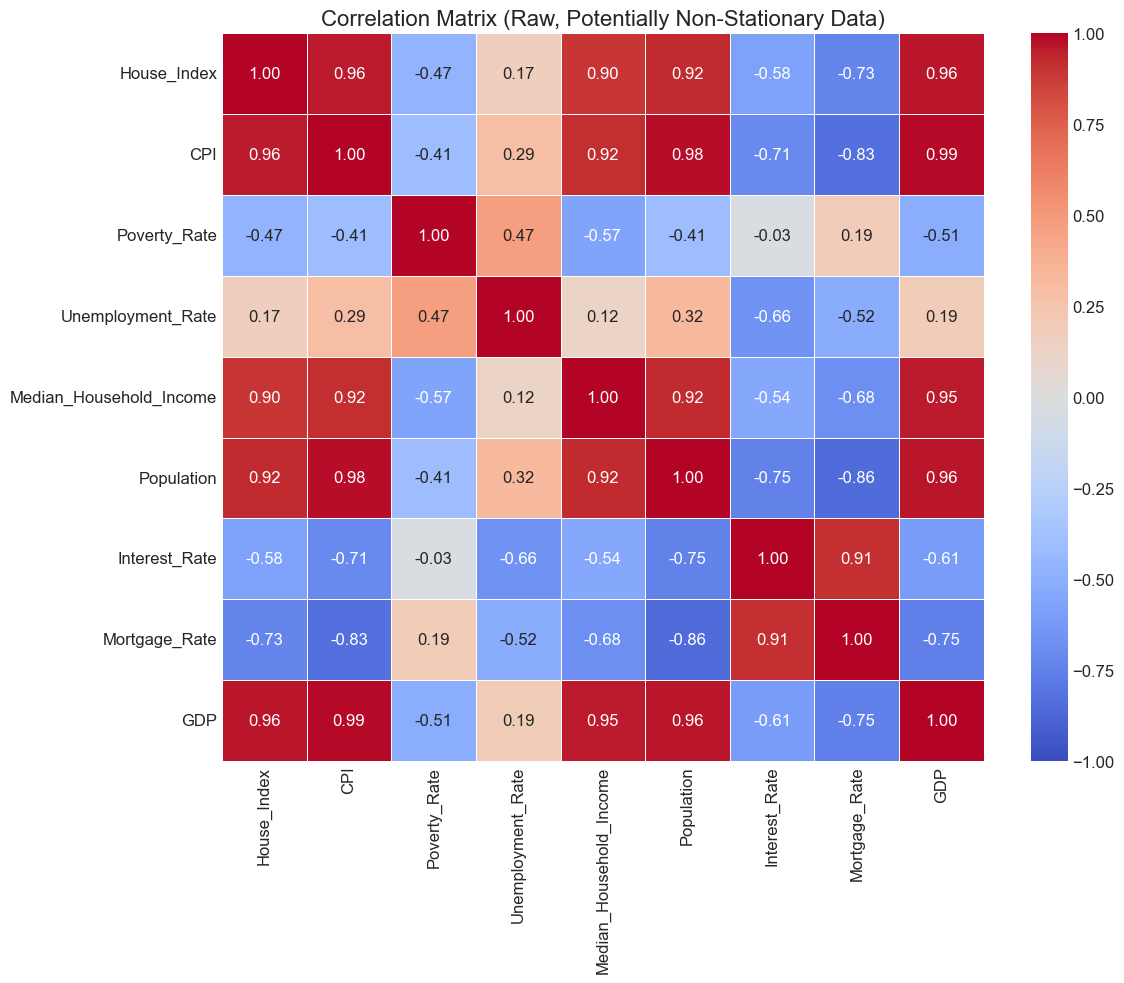


--- 2. Time Series Visualization ---
Plotting all time series variables...


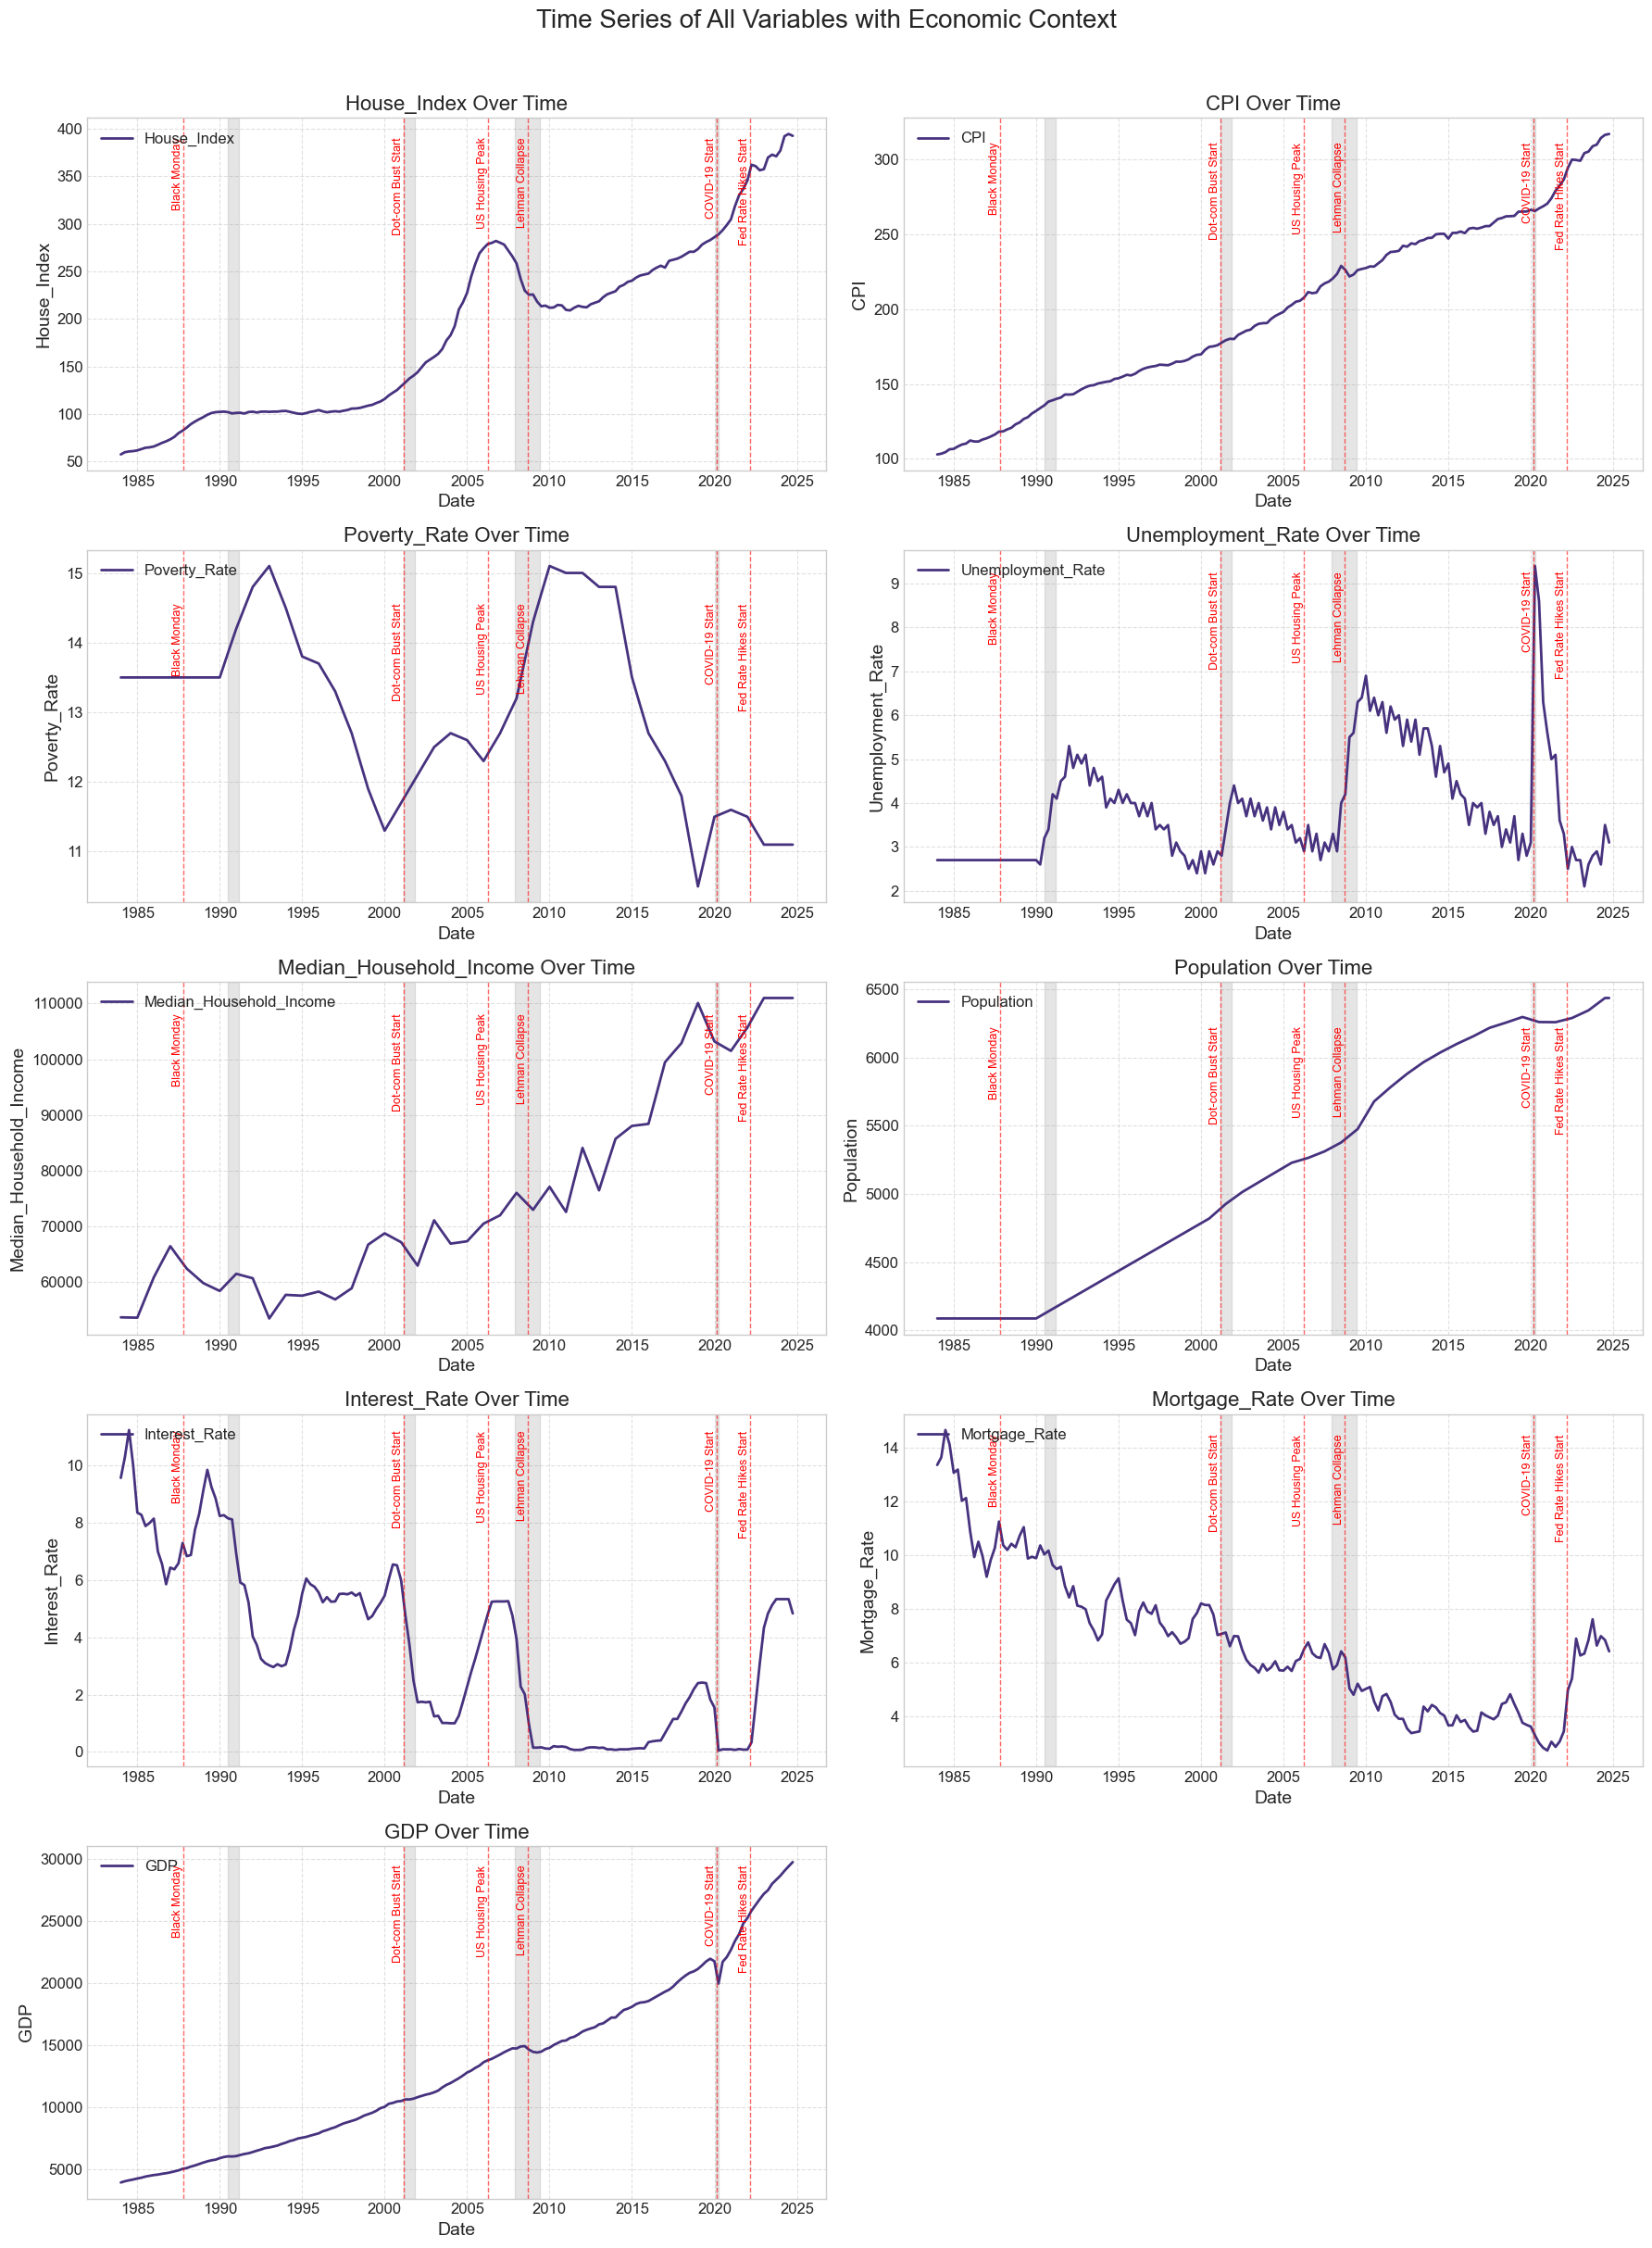

Plotting target variable (House_Index) in detail...


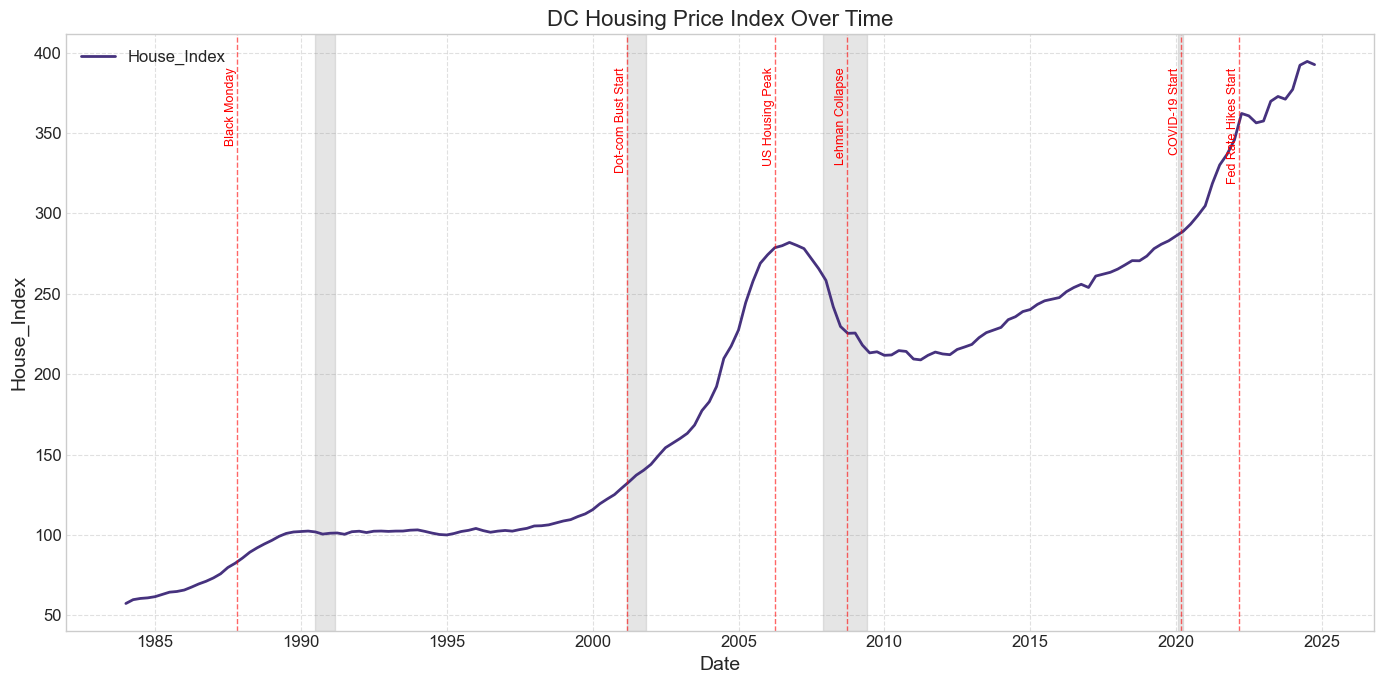


--- 3. Stationarity Analysis ---

Testing stationarity of original variables:

--- Analyzing: House_Index ---


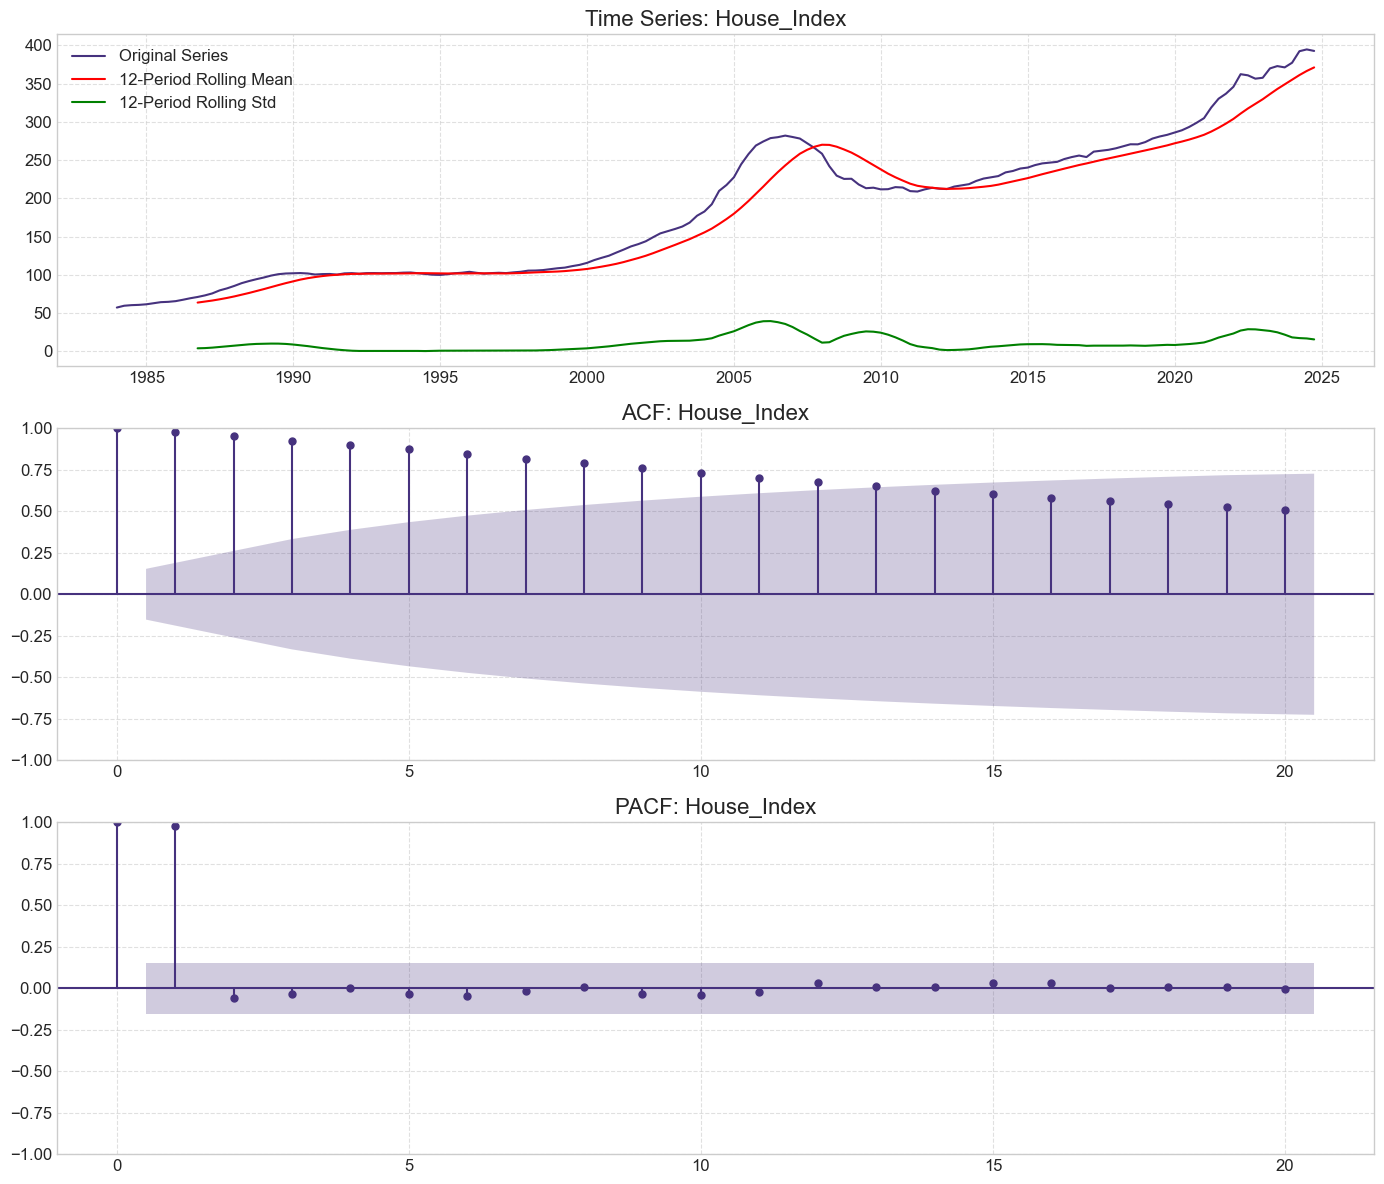

ADF Test (House_Index): Stat=0.182, p=0.971 -> Non-Stationary
KPSS Test (House_Index): Stat=1.754, p=0.010 -> Non-Stationary
Overall (House_Index): Both tests suggest NON-STATIONARY.

--- Analyzing: CPI ---


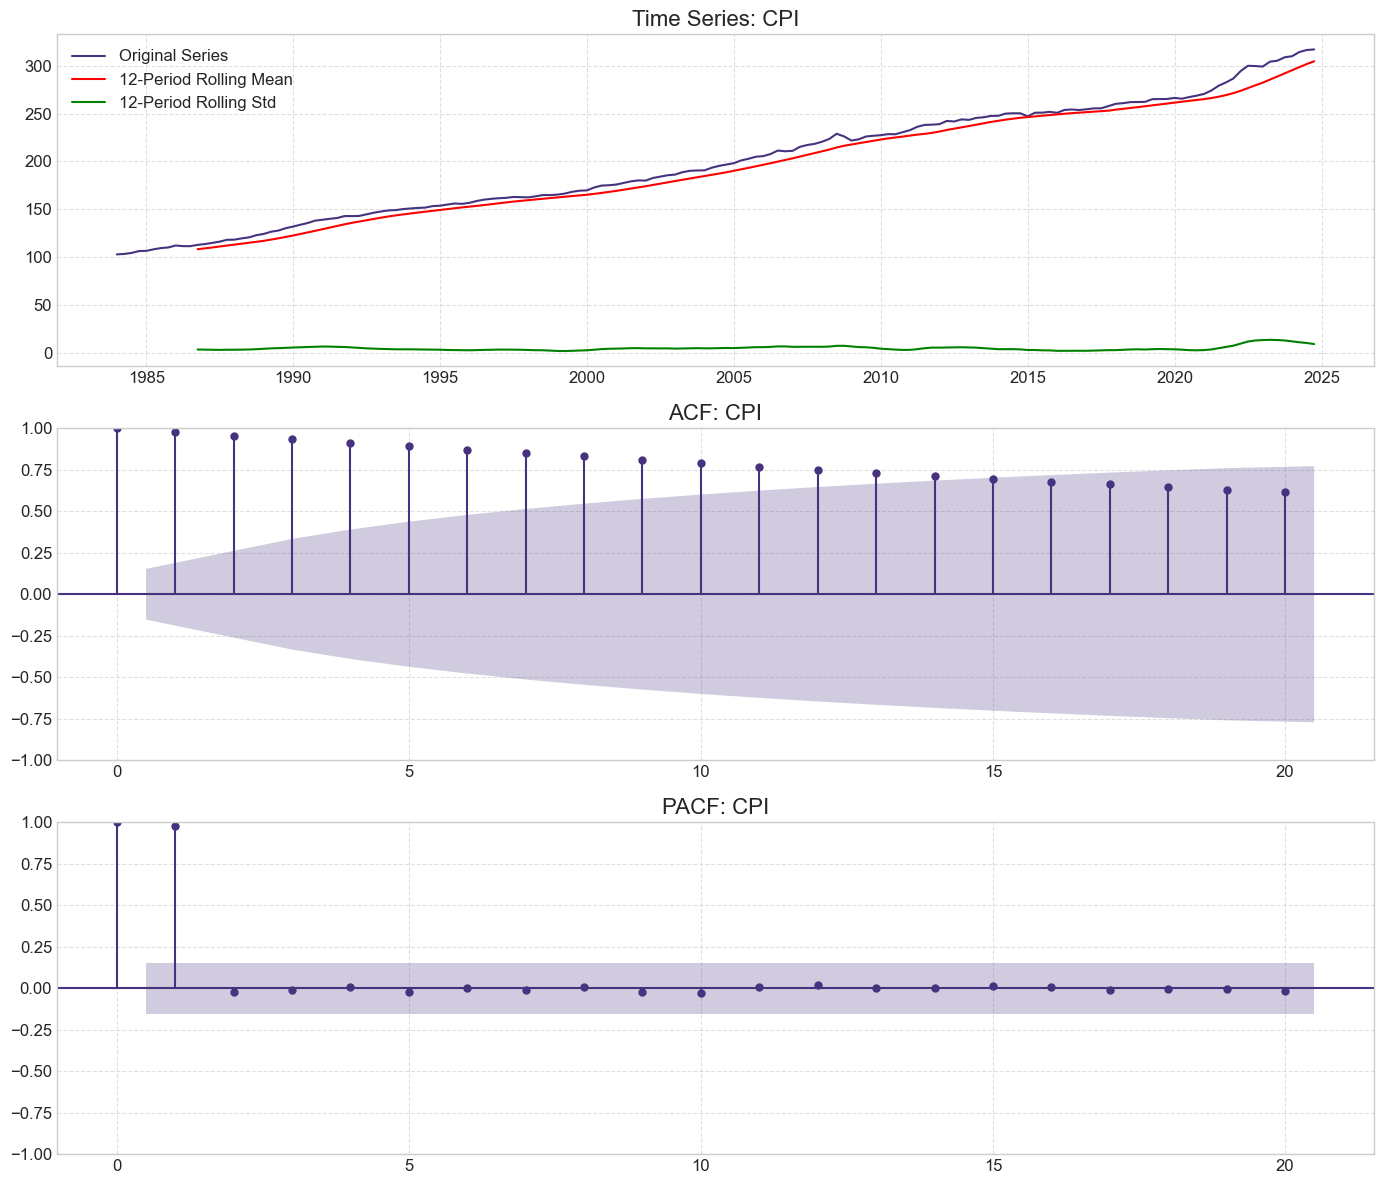

ADF Test (CPI): Stat=0.987, p=0.994 -> Non-Stationary
KPSS Test (CPI): Stat=1.920, p=0.010 -> Non-Stationary
Overall (CPI): Both tests suggest NON-STATIONARY.

--- Analyzing: Poverty_Rate ---


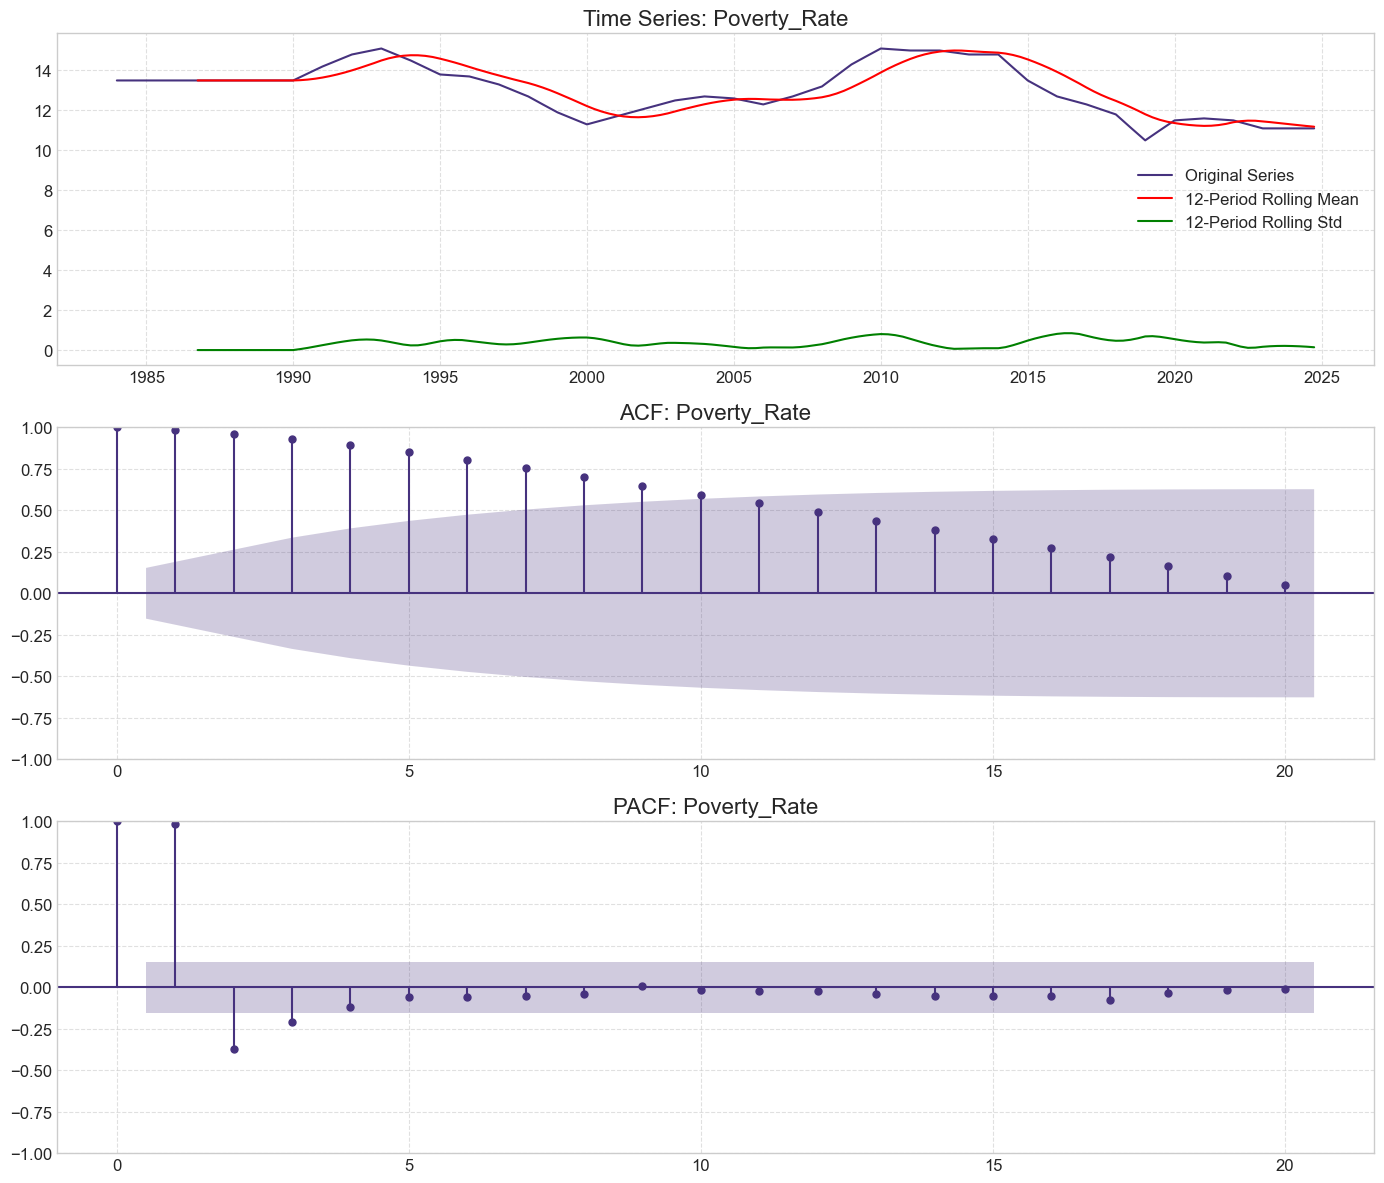

ADF Test (Poverty_Rate): Stat=-2.195, p=0.208 -> Non-Stationary
KPSS Test (Poverty_Rate): Stat=0.447, p=0.057 -> Stationary
Overall (Poverty_Rate): Tests CONFLICT (ADF: NonStat, KPSS: Stat). **Treating as Non-Stationary for differencing.**

--- Analyzing: Unemployment_Rate ---


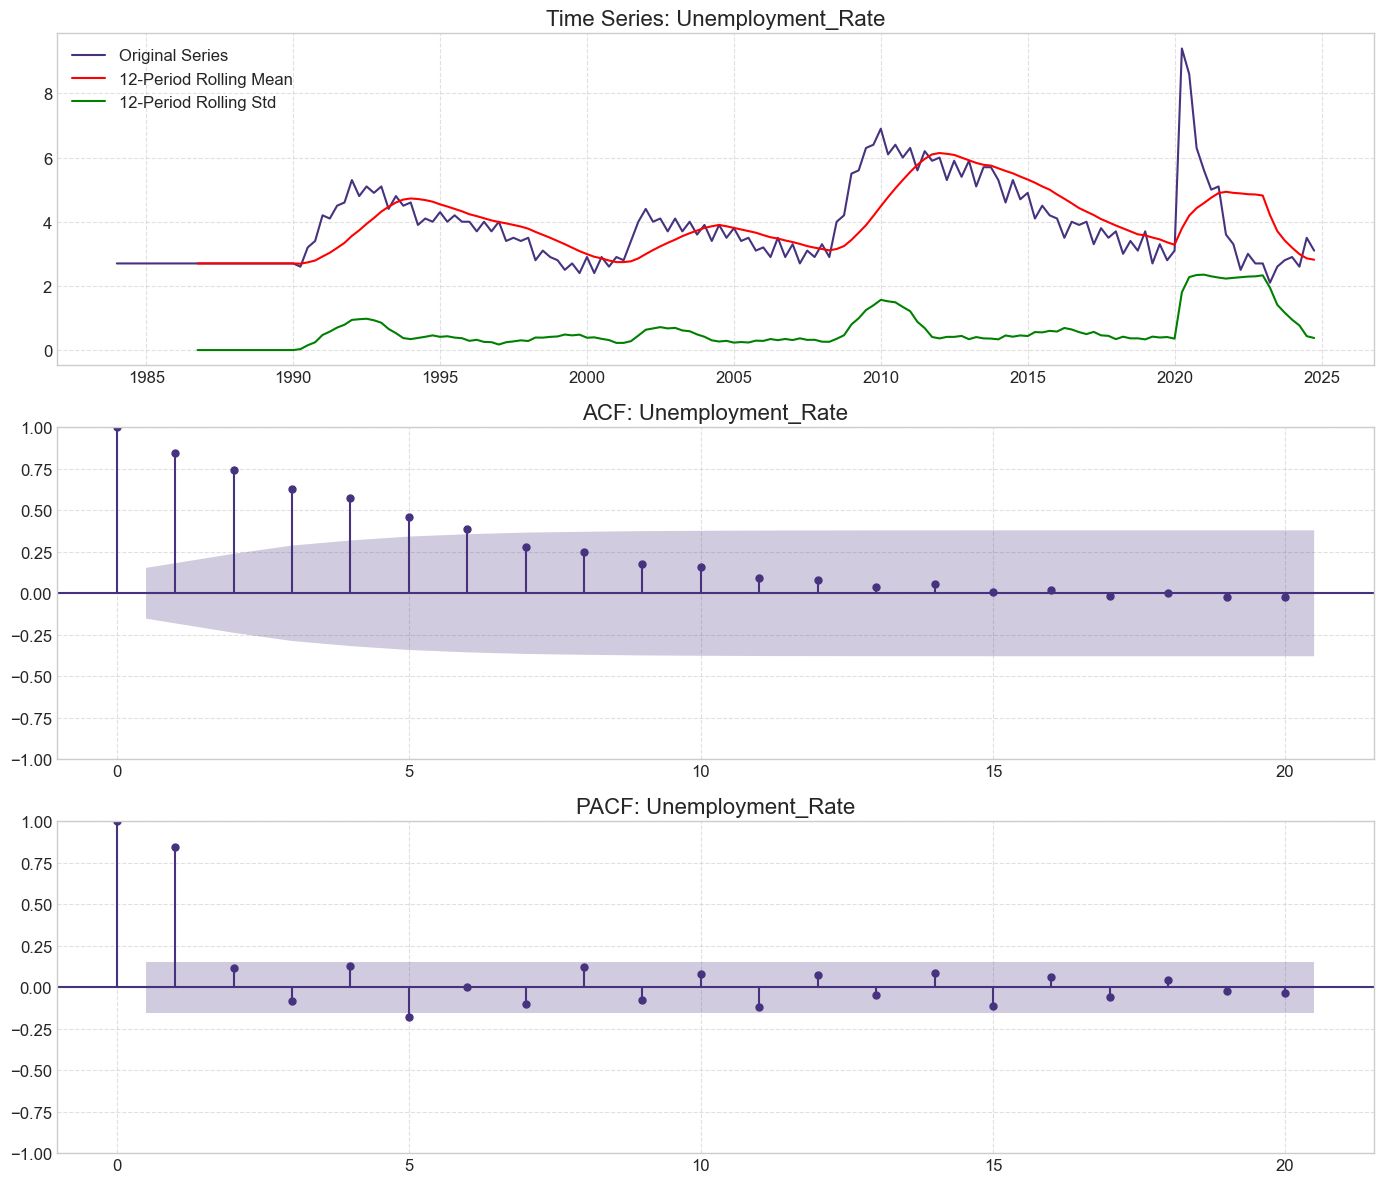

ADF Test (Unemployment_Rate): Stat=-3.242, p=0.018 -> Stationary
KPSS Test (Unemployment_Rate): Stat=0.381, p=0.085 -> Stationary
Overall (Unemployment_Rate): Both tests suggest STATIONARY.

--- Analyzing: Median_Household_Income ---


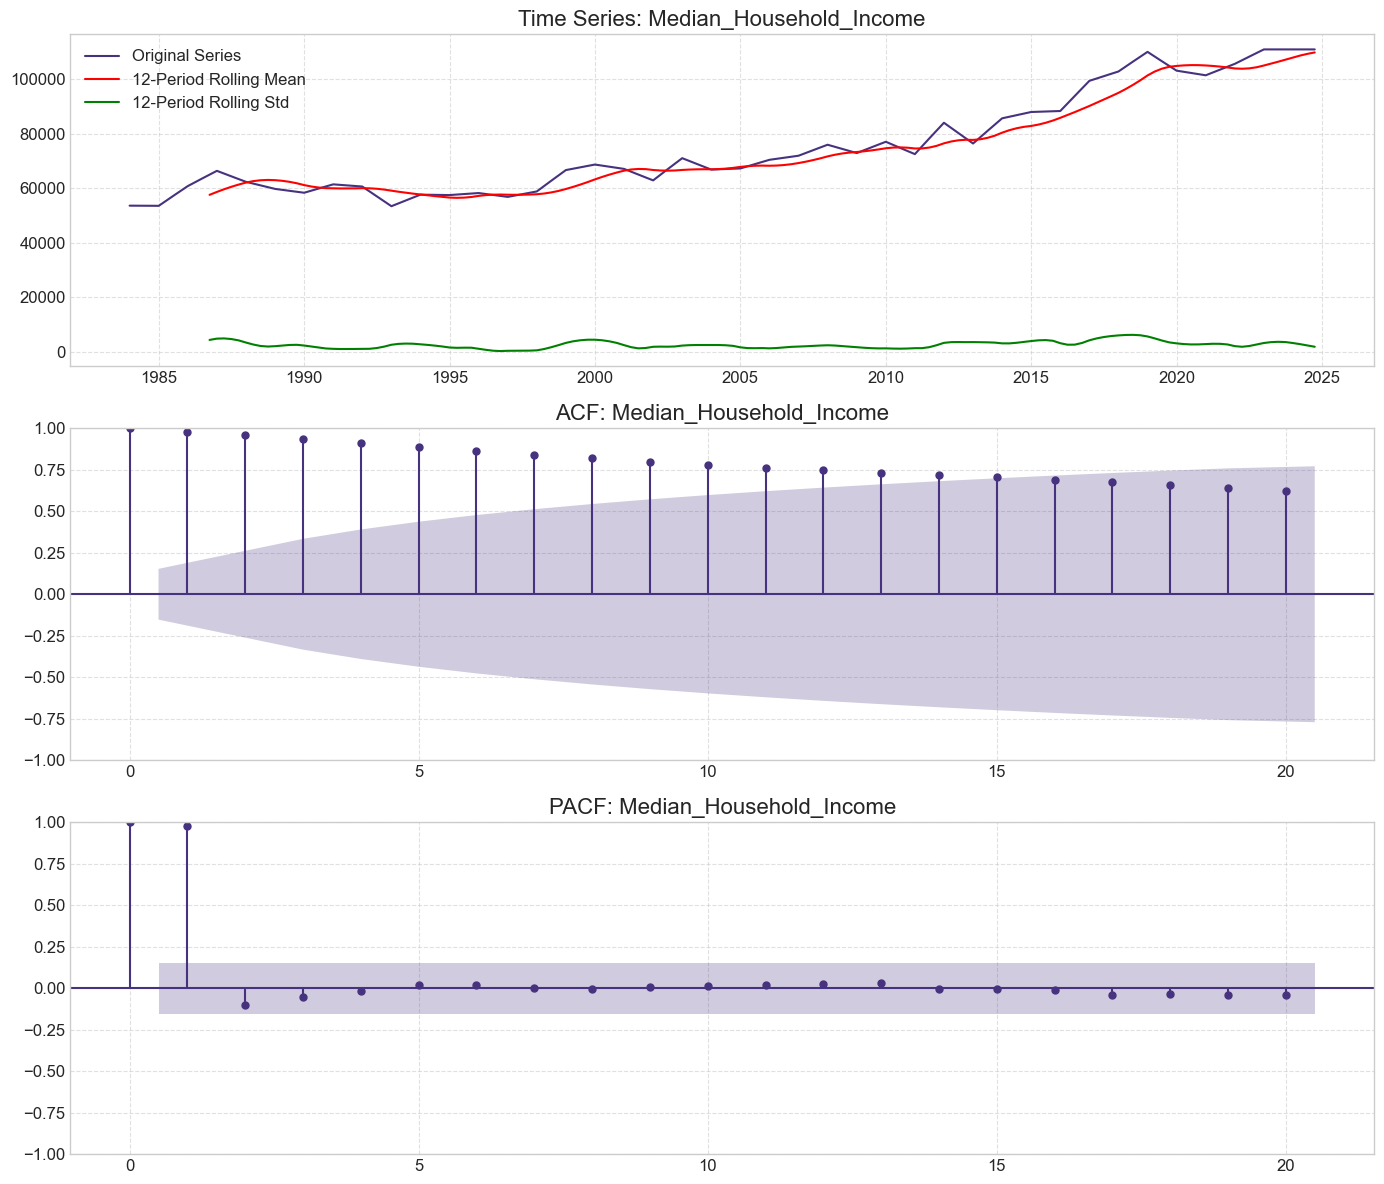

ADF Test (Median_Household_Income): Stat=1.038, p=0.995 -> Non-Stationary
KPSS Test (Median_Household_Income): Stat=1.709, p=0.010 -> Non-Stationary
Overall (Median_Household_Income): Both tests suggest NON-STATIONARY.

--- Analyzing: Population ---


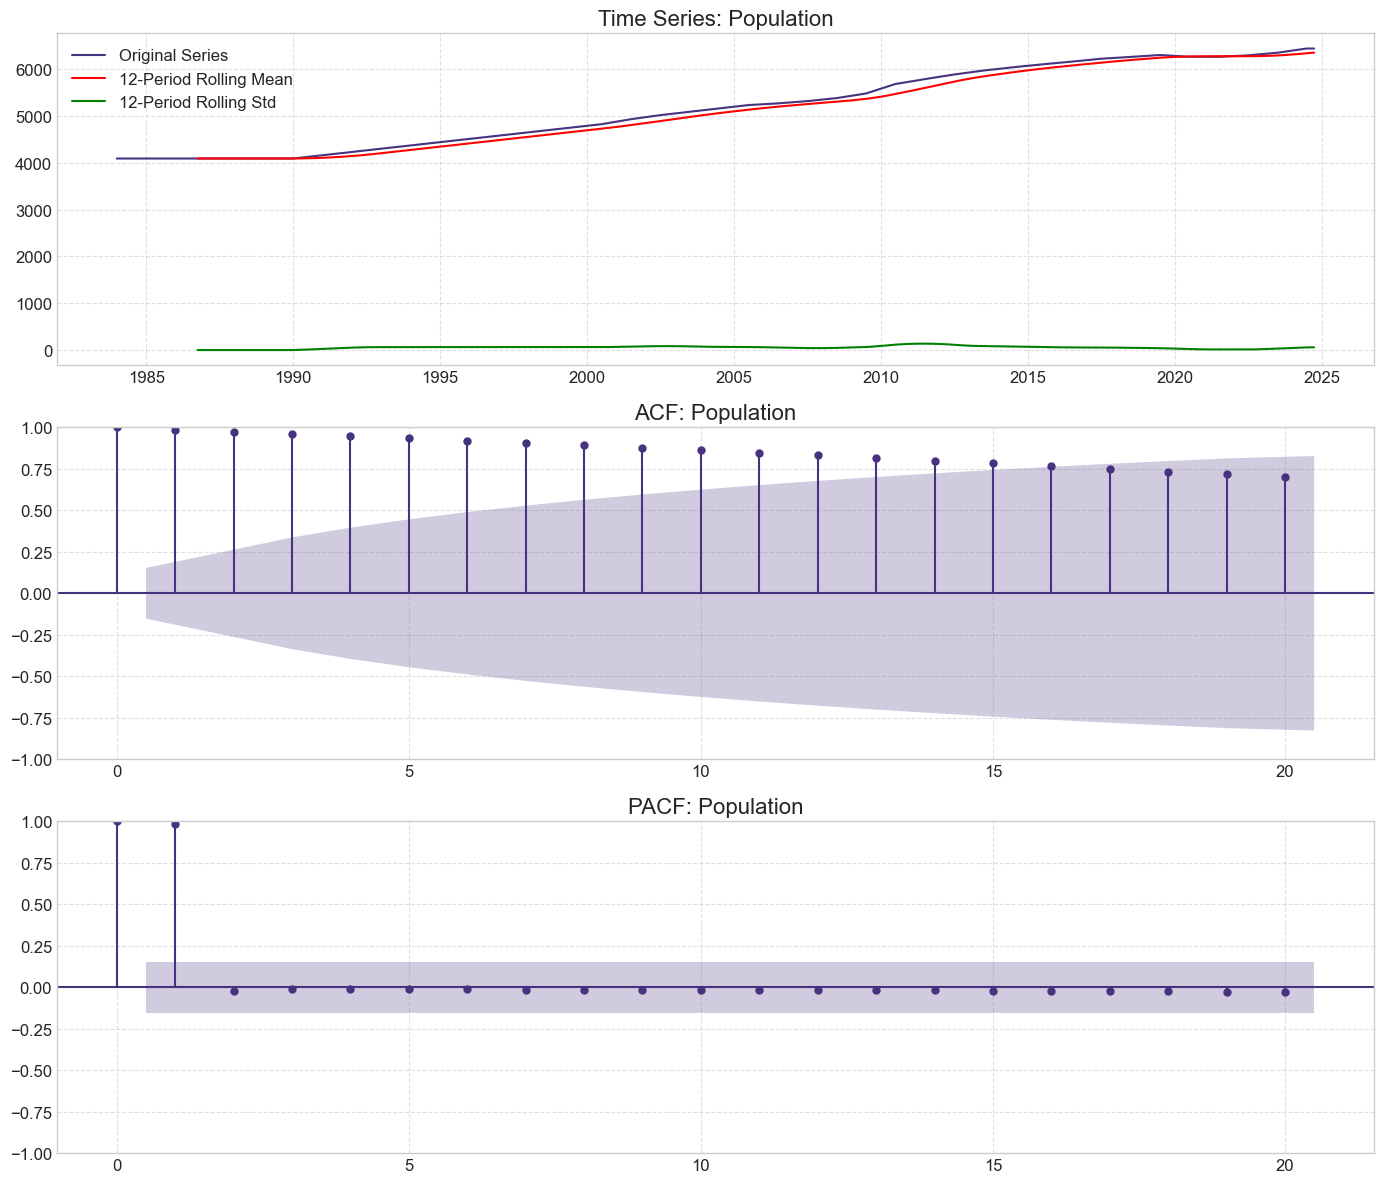

ADF Test (Population): Stat=-0.686, p=0.850 -> Non-Stationary
KPSS Test (Population): Stat=1.914, p=0.010 -> Non-Stationary
Overall (Population): Both tests suggest NON-STATIONARY.

--- Analyzing: Interest_Rate ---


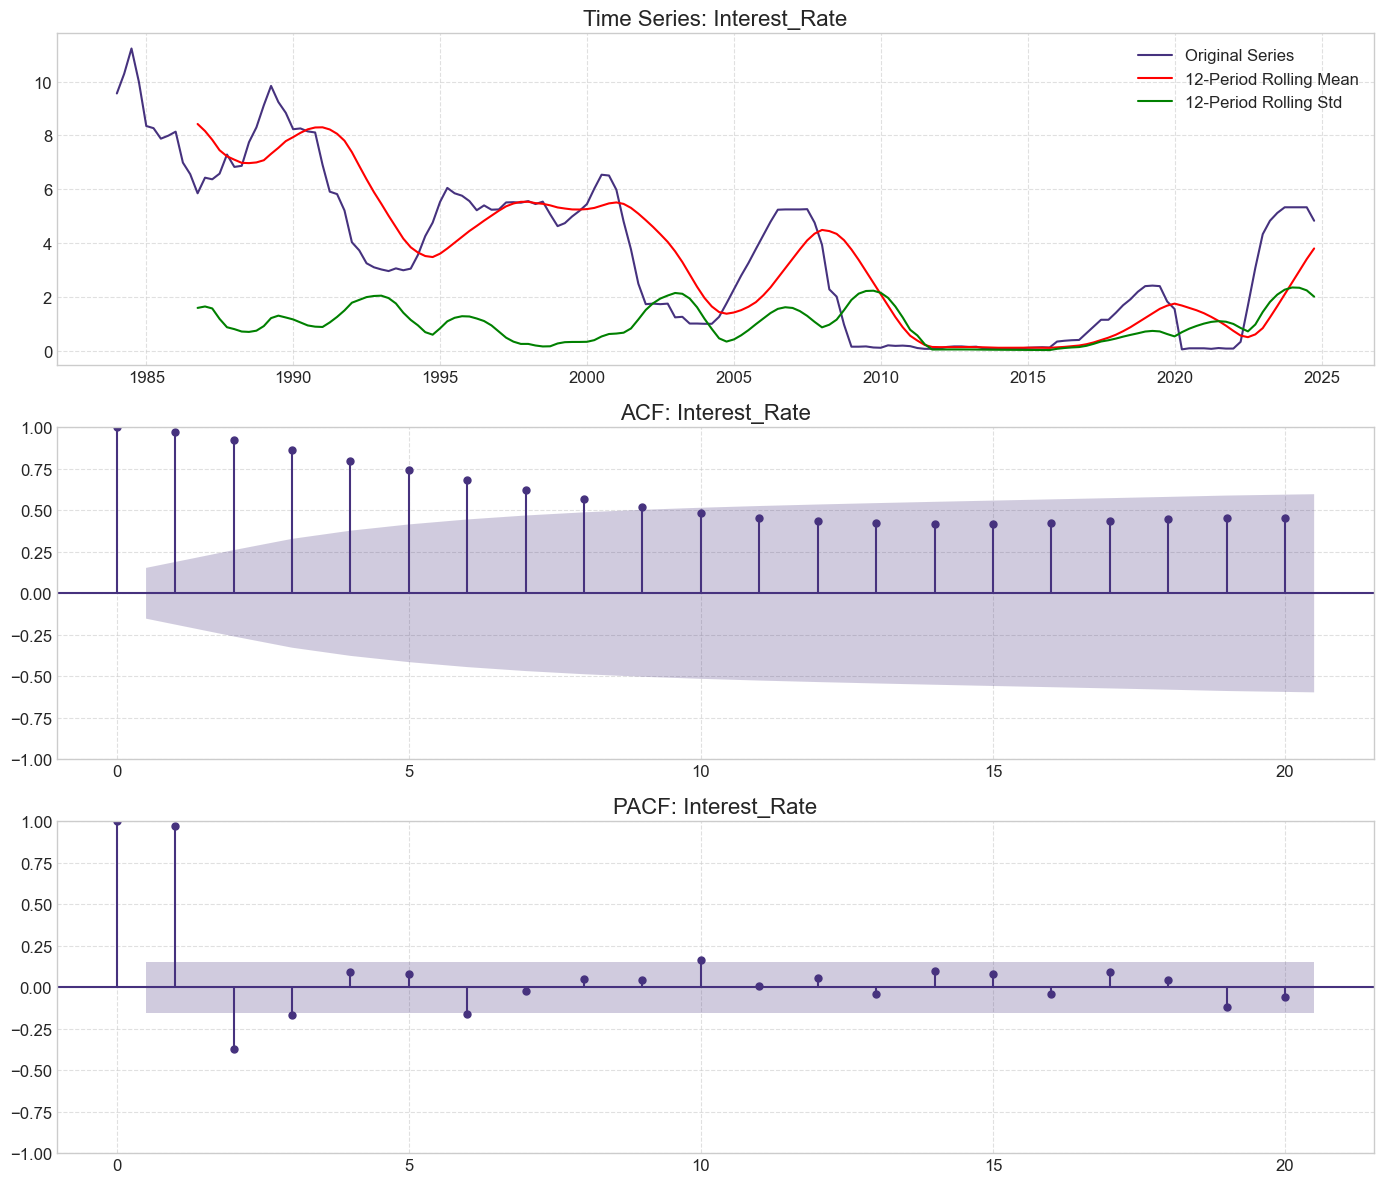

ADF Test (Interest_Rate): Stat=-3.377, p=0.012 -> Stationary
KPSS Test (Interest_Rate): Stat=1.289, p=0.010 -> Non-Stationary
Overall (Interest_Rate): Tests CONFLICT (ADF: Stat, KPSS: NonStat). **Treating as Non-Stationary for differencing.**

--- Analyzing: Mortgage_Rate ---


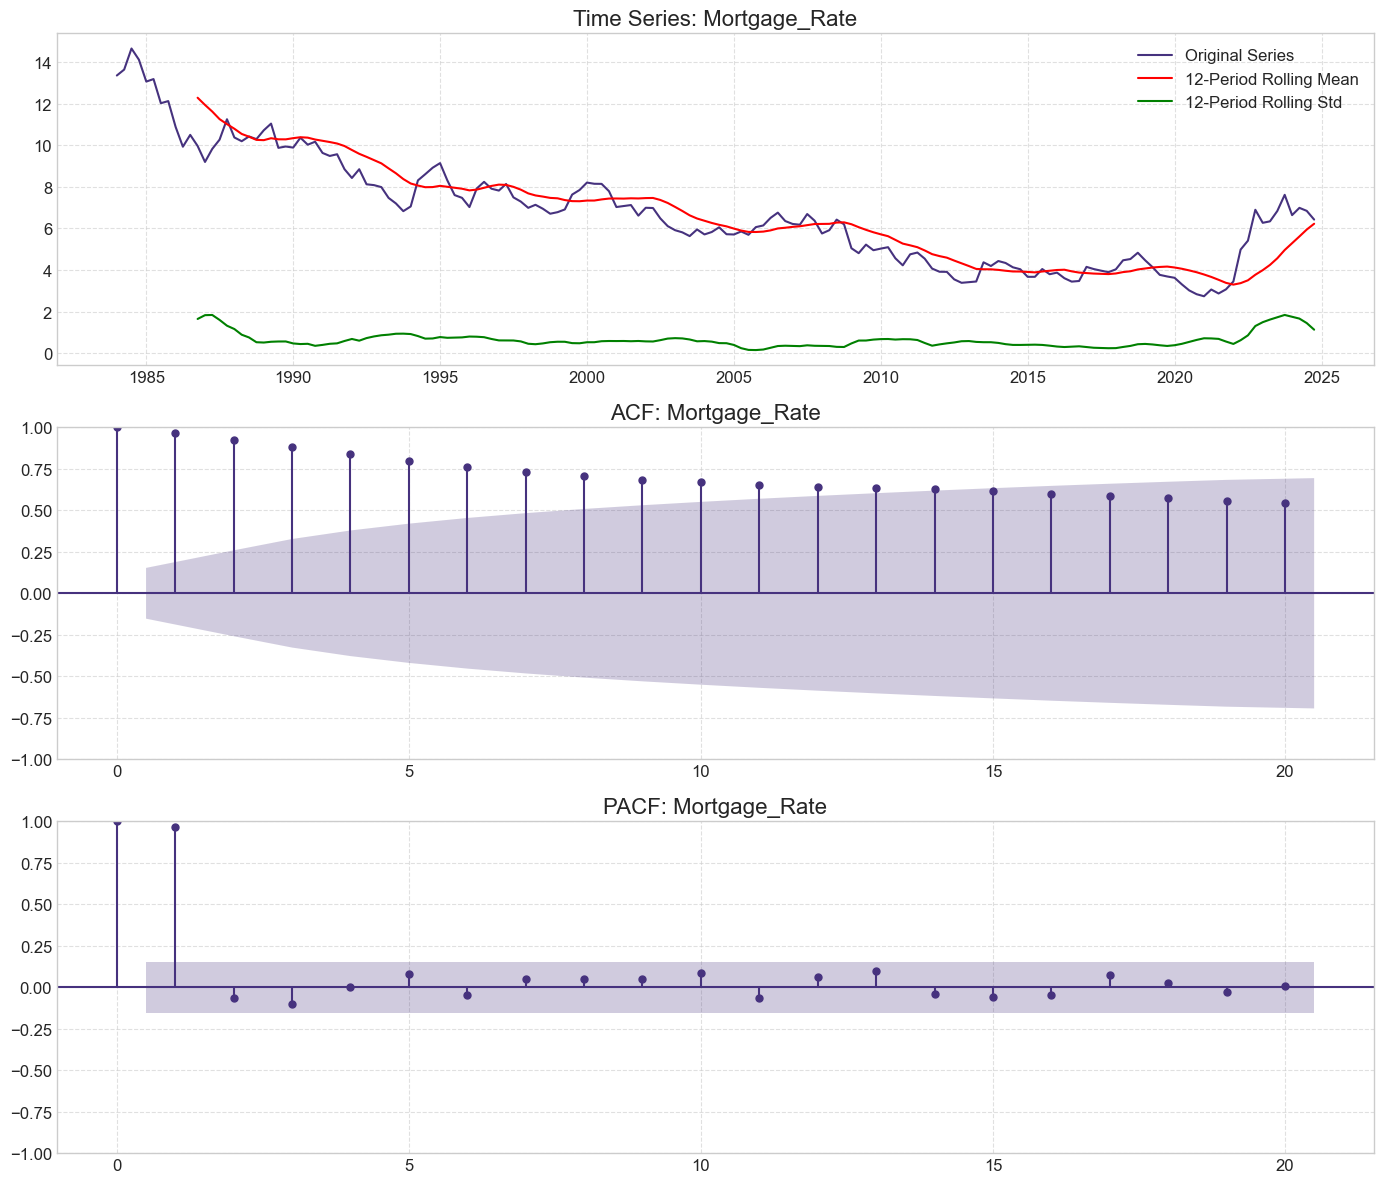

ADF Test (Mortgage_Rate): Stat=-2.560, p=0.101 -> Non-Stationary
KPSS Test (Mortgage_Rate): Stat=1.613, p=0.010 -> Non-Stationary
Overall (Mortgage_Rate): Both tests suggest NON-STATIONARY.

--- Analyzing: GDP ---


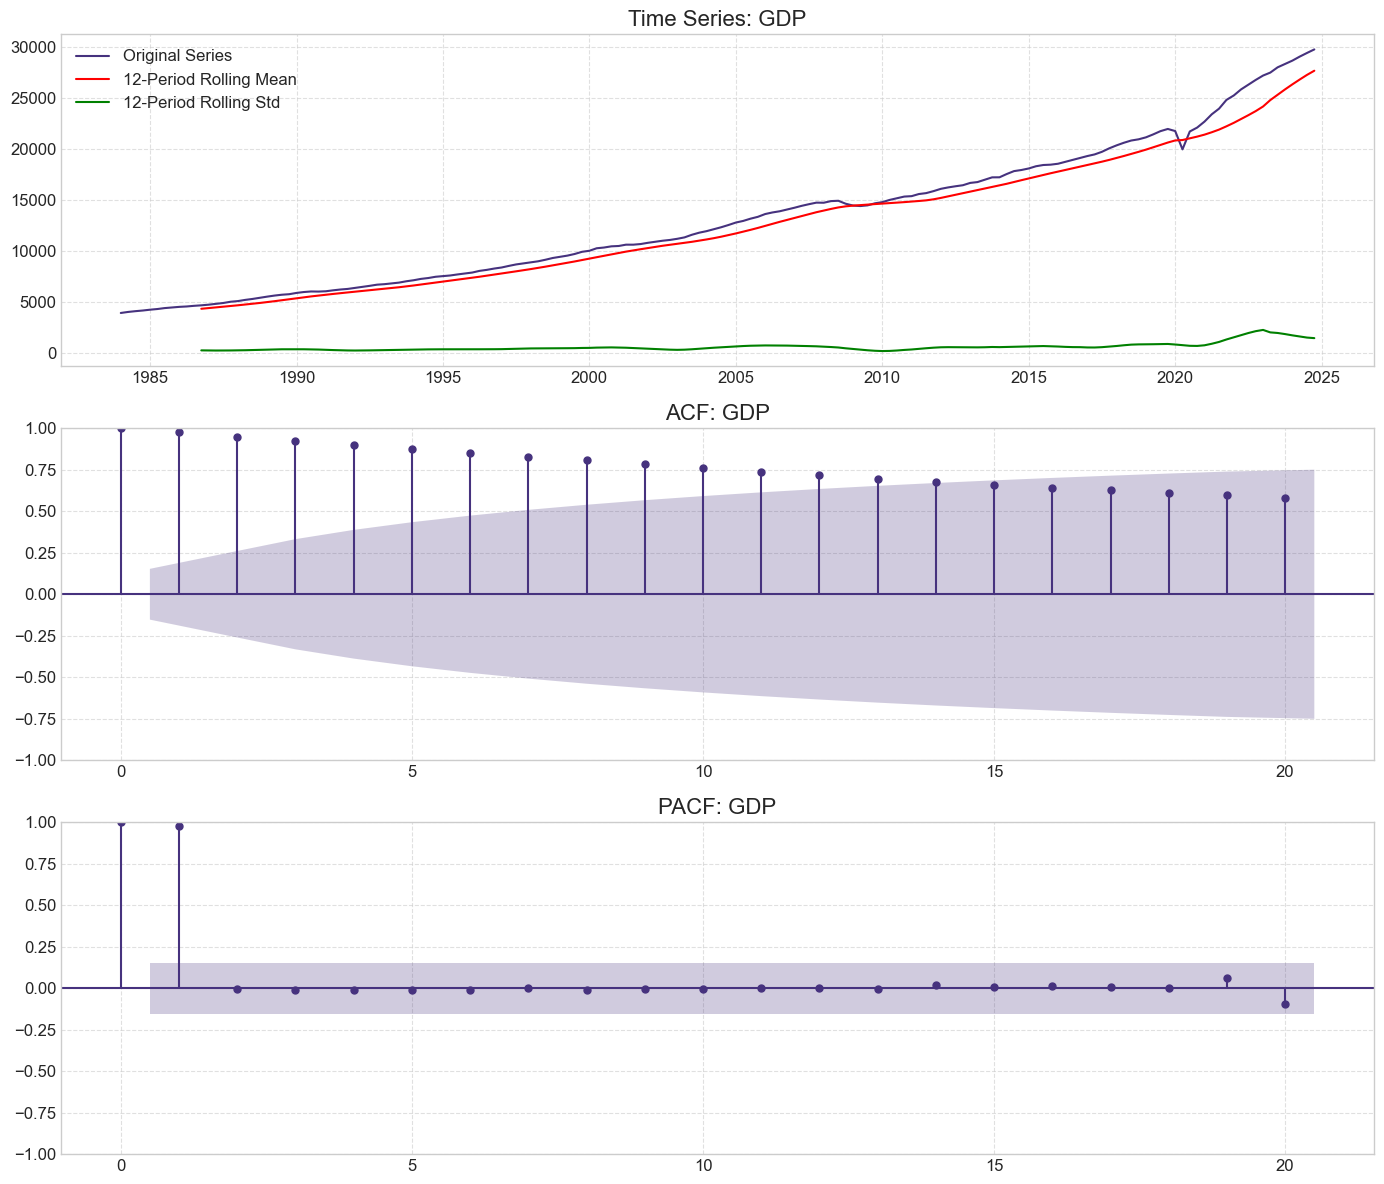

ADF Test (GDP): Stat=4.636, p=1.000 -> Non-Stationary
KPSS Test (GDP): Stat=1.860, p=0.010 -> Non-Stationary
Overall (GDP): Both tests suggest NON-STATIONARY.

Stationarity Test Summary (Original Data):
                            adf_p adf_stationary    kpss_p kpss_stationary  \
House_Index              0.971227          False      0.01           False   
CPI                      0.994128          False      0.01           False   
Poverty_Rate             0.208042          False  0.057052            True   
Unemployment_Rate        0.017685           True  0.085163            True   
Median_Household_Income  0.994652          False      0.01           False   
Population               0.850255          False      0.01           False   
Interest_Rate            0.011752           True      0.01           False   
Mortgage_Rate              0.1015          False      0.01           False   
GDP                           1.0          False      0.01           False   

                

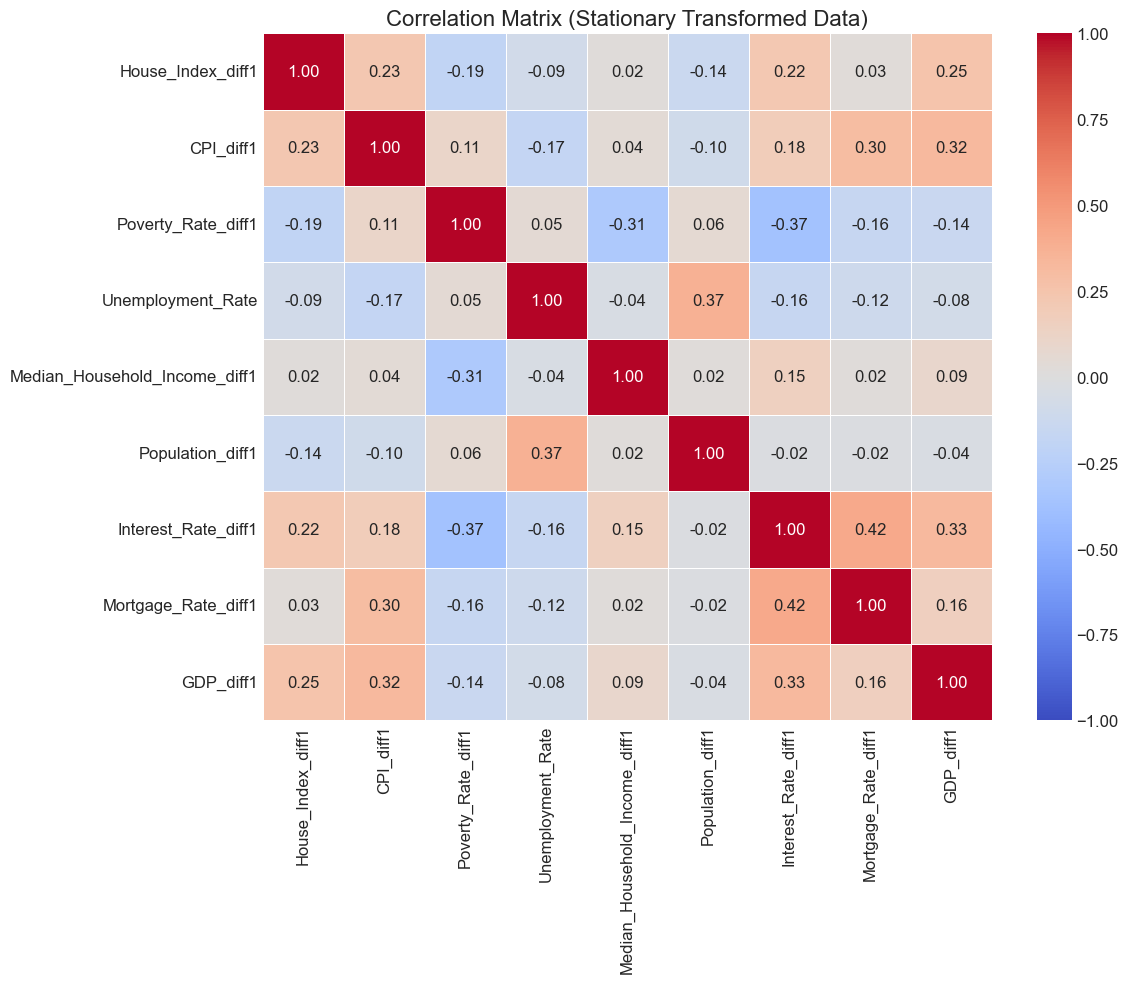


Analyzing Lead-Lag Correlations with Target: House_Index_diff1
- CPI_diff1: Max abs correlation (0.23) at lag 0
- Poverty_Rate_diff1: Max abs correlation (-0.19) at lag 0
- Unemployment_Rate: Max abs correlation (0.11) at lag -3
- Median_Household_Income_diff1: Max abs correlation (-0.09) at lag -5
- Population_diff1: Max abs correlation (-0.15) at lag -3
- Interest_Rate_diff1: Max abs correlation (0.23) at lag -1
- Mortgage_Rate_diff1: Max abs correlation (0.10) at lag -2
- GDP_diff1: Max abs correlation (0.25) at lag 0


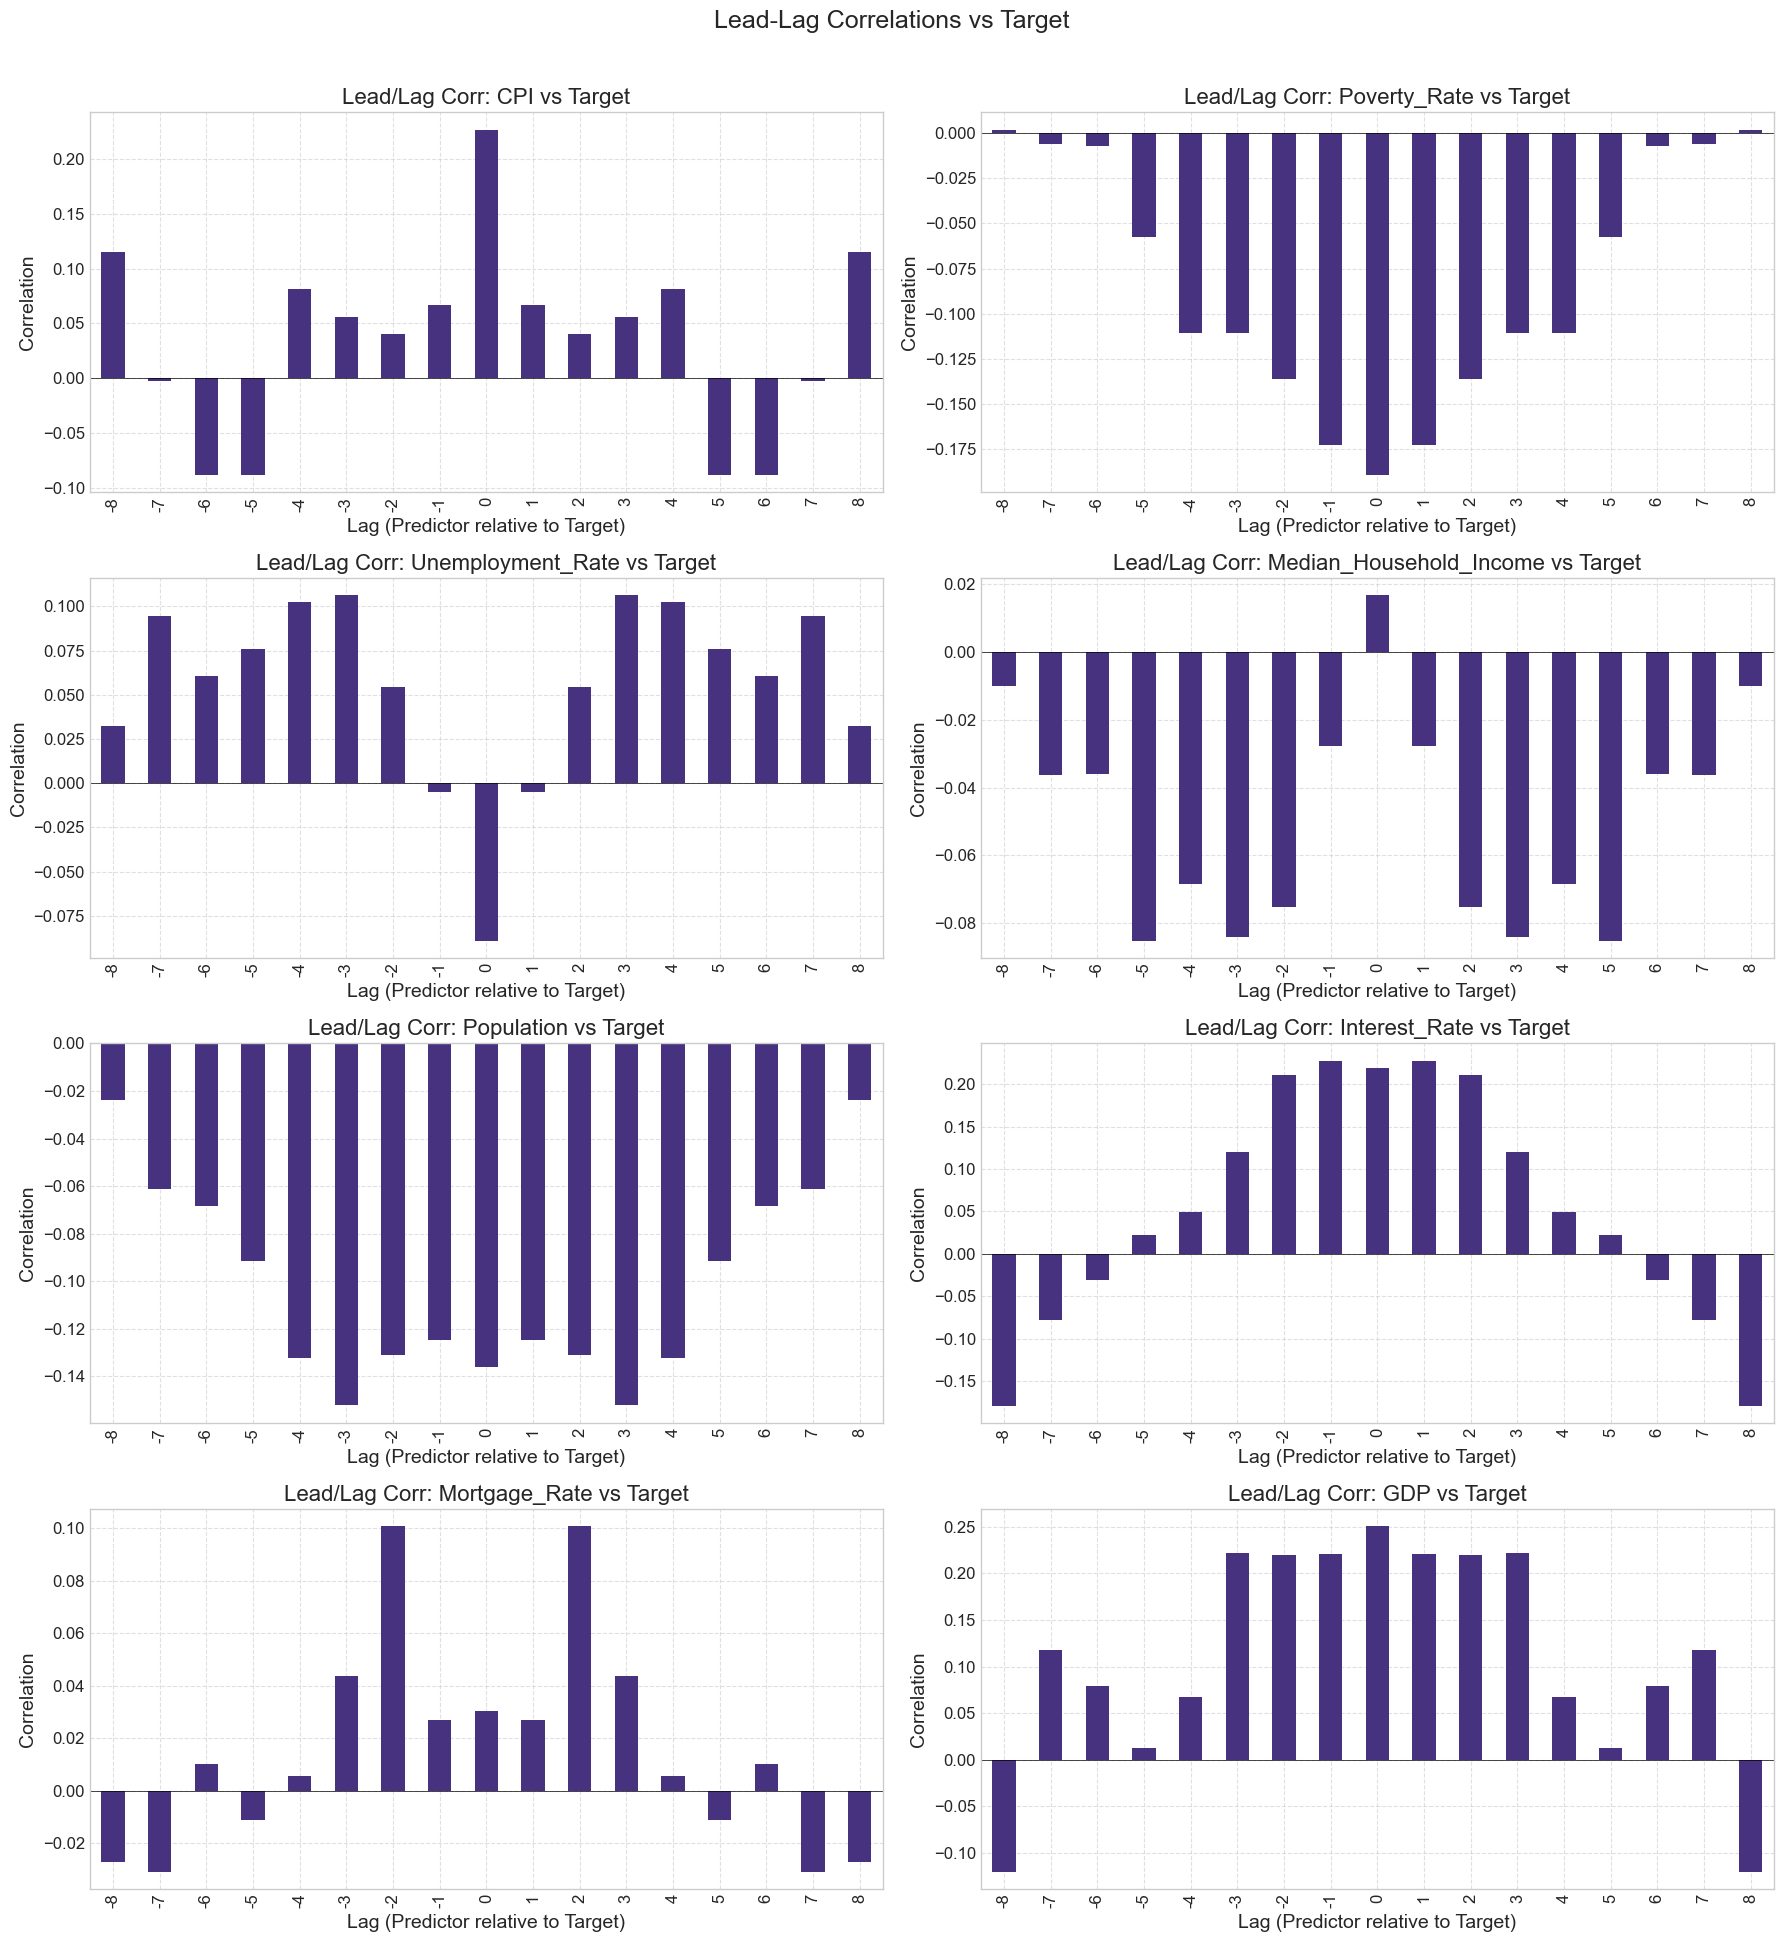


Granger Causality Tests (Predictor -> House_Index_diff1):

-- Testing if CPI_diff1 Granger-causes House_Index_diff1 --
Result: Significant (min significant p=0.0413 at lag 3)

-- Testing if Poverty_Rate_diff1 Granger-causes House_Index_diff1 --
Result: Not Significant (min significant p=0.4333 at lag N/A)

-- Testing if Unemployment_Rate Granger-causes House_Index_diff1 --
Result: Not Significant (min significant p=0.0675 at lag N/A)

-- Testing if Median_Household_Income_diff1 Granger-causes House_Index_diff1 --
Result: Not Significant (min significant p=0.5176 at lag N/A)

-- Testing if Population_diff1 Granger-causes House_Index_diff1 --
Result: Not Significant (min significant p=0.2429 at lag N/A)

-- Testing if Interest_Rate_diff1 Granger-causes House_Index_diff1 --
Result: Not Significant (min significant p=0.1466 at lag N/A)

-- Testing if Mortgage_Rate_diff1 Granger-causes House_Index_diff1 --
Result: Not Significant (min significant p=0.3658 at lag N/A)

-- Testing if GDP_dif

In [15]:
# -*- coding: utf-8 -*-
"""
Revised Exploratory Data Analysis (EDA) for DC Housing Market Data (v4)

Goal: Prepare data for time series forecasting, ensuring rigorous statistical
      due process, proper transformations, feature engineering, and setup
      for cross-validated modeling.

Update v2: Corrected handling of variables with conflicting stationarity tests.
Update v3: Corrected data cutoff logic to use last valid target date before imputation.
Update v4: Made data cutoff filtering more explicit using .loc before imputation.
"""

# %% 0. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import skew, kurtosis, shapiro
import warnings
from datetime import datetime

# Ignore common warnings
warnings.filterwarnings('ignore')

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 7) # Larger default figure size
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# %% 1. Initial Data Loading and Examination
# ==========================================
print("--- 1. Initial Data Loading and Examination ---")

# Load the dataset
try:
    df_raw = pd.read_csv('DC_Master_Data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: DC_Master_Data.csv not found. Please ensure the file is in the correct directory.")
    exit() # Exit if data cannot be loaded

# --- Data Cleaning and Preprocessing ---
# Convert 'Date' column to datetime objects
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Set 'Date' as the index
df_raw = df_raw.set_index('Date')

# Ensure chronological order
df_raw = df_raw.sort_index()

# --- STRICT DATA CUTOFF ---
# Find the last date where the target variable ('House_Index') is not NaN
last_valid_target_date = df_raw['House_Index'].last_valid_index()

if last_valid_target_date is None:
     print("Error: No valid data found for the target variable 'House_Index'.")
     exit()

print(f"Last valid date for target 'House_Index' found in raw data: {last_valid_target_date.strftime('%Y-%m-%d')}")

# Filter the DataFrame using .loc to include data UP TO AND INCLUDING that date
# This happens BEFORE any imputation.
df = df_raw.loc[:last_valid_target_date].copy()
print(f"Strictly filtered data to include dates up to {last_valid_target_date.strftime('%Y-%m-%d')}")
# --- END STRICT CUTOFF ---


# --- Basic Information ---
print(f"\nDataset dimensions after strict cutoff: {df.shape[0]} rows × {df.shape[1]} columns")
if not df.empty:
    print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
    duration_years = (df.index.max() - df.index.min()).days / 365.25
    print(f"Duration: {duration_years:.1f} years")
    # Infer frequency
    inferred_freq = pd.infer_freq(df.index)
    if inferred_freq:
        print(f"Inferred Frequency: {inferred_freq}")
    else:
        # Attempt to set frequency if inference fails but index is monotonic quarterly
        if df.index.is_monotonic_increasing and len(df.index) > 1:
             # Check if differences are consistent with quarterly
             diffs = df.index.to_series().diff().dropna()
             if (diffs >= pd.Timedelta(days=80)) & (diffs <= pd.Timedelta(days=100)):
                  print("Warning: Could not infer frequency automatically, but data looks quarterly. Setting manually to 'QS'.")
                  df.index.freq = 'QS' # Or try 'QS-OCT' if appropriate start month known
                  inferred_freq = df.index.freq
             else:
                  print("Warning: Could not infer frequency and data doesn't appear regularly quarterly.")
        else:
             print("Warning: Could not infer frequency.")

else:
    print("Dataset is empty after filtering.")
    exit()

# --- Missing Value Analysis ---
print("\nMissing values before handling (after strict cutoff):")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

# Handle missing values - Use forward fill first, then backward fill
# Applied only to the correctly truncated dataframe 'df'
df_filled = df.fillna(method='ffill')
df_filled = df_filled.fillna(method='bfill')
missing_after = df_filled.isnull().sum().sum()
print(f"\nMissing values after ffill/bfill: {missing_after}")
if missing_after > 0:
    print("Warning: Missing values remain after filling. Further investigation needed.")
    # Consider more sophisticated imputation if required (e.g., interpolation, model-based)
df = df_filled # Assign the filled dataframe back

# --- Descriptive Statistics ---
print("\nDescriptive Statistics:")
desc_stats = df.describe().T
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['CV'] = (desc_stats['std'] / desc_stats['mean']).abs() * 100 # Coefficient of Variation
desc_stats['Skewness'] = df.skew()
desc_stats['Kurtosis'] = df.kurtosis() # Fisher's definition (normal=0)
print(desc_stats[['mean', 'std', 'min', 'max', 'IQR', 'CV', 'Skewness', 'Kurtosis']])

# --- Outlier Detection (using IQR method) ---
print("\nPotential outliers based on IQR method:")
outlier_counts = {}
for col in df.columns:
    Q1 = desc_stats.loc[col, '25%']
    Q3 = desc_stats.loc[col, '75%']
    IQR = desc_stats.loc[col, 'IQR']
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_counts[col] = outliers.count()
    if outliers.count() > 0:
        print(f"- {col}: {outliers.count()} potential outliers")
        # print(outliers) # Uncomment to see outlier values and dates

# --- Initial Correlation (Raw Data) ---
print("\nInitial Correlation Matrix (Raw Data - Use with Caution):")
corr_matrix_raw = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_raw, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Raw, Potentially Non-Stationary Data)')
plt.tight_layout()
plt.show()

# %% 2. Time Series Visualization
# =============================
# (Code remains the same as previous version)
print("\n--- 2. Time Series Visualization ---")
economic_events = {
    '1987-10-19': 'Black Monday', '2001-03-01': 'Dot-com Bust Start',
    '2006-04-01': 'US Housing Peak', '2008-09-15': 'Lehman Collapse',
    '2020-03-01': 'COVID-19 Start', '2022-03-01': 'Fed Rate Hikes Start'}
recessions = [
    ('1980-01-01', '1980-07-01'), ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'), ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'), ('2020-02-01', '2020-04-01')]
def plot_time_series_with_context(series, title=None, ylabel=None, ax=None, plot_events=True, plot_recessions=True):
    if ax is None: fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(series.index, series.values, label=series.name, linewidth=2)
    if plot_recessions:
        for start, end in recessions:
            start_dt, end_dt = pd.to_datetime(start), pd.to_datetime(end)
            if start_dt < series.index.max() and end_dt > series.index.min():
                 ax.axvspan(max(start_dt, series.index.min()), min(end_dt, series.index.max()), color='gray', alpha=0.2, label='_nolegend_')
    if plot_events:
        for date, event in economic_events.items():
            date_obj = pd.to_datetime(date)
            if series.index.min() <= date_obj <= series.index.max():
                ax.axvline(date_obj, color='red', linestyle='--', alpha=0.6, linewidth=1)
                ax.text(date_obj, ax.get_ylim()[1]*0.95, event, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=9, color='red')
    ax.set_title(title or f'{series.name} Over Time', fontsize=16)
    ax.set_xlabel('Date', fontsize=14); ax.set_ylabel(ylabel or series.name, fontsize=14)
    ax.legend(loc='upper left'); ax.grid(True, linestyle='--', alpha=0.6)
    return ax
print("Plotting all time series variables...")
n_plots = len(df.columns); n_cols_grid = 2; n_rows_grid = (n_plots + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 5 * n_rows_grid), squeeze=False)
axes_flat = axes.flatten()
for i, col in enumerate(df.columns): plot_time_series_with_context(df[col], ax=axes_flat[i])
for j in range(i + 1, len(axes_flat)): fig.delaxes(axes_flat[j])
plt.tight_layout(rect=[0, 0.03, 1, 0.97]); fig.suptitle('Time Series of All Variables with Economic Context', fontsize=20, y=1.0); plt.show()
print("Plotting target variable (House_Index) in detail...")
fig_target, ax_target = plt.subplots(figsize=(14, 7)); plot_time_series_with_context(df['House_Index'], ax=ax_target, title='DC Housing Price Index Over Time'); plt.tight_layout(); plt.show()


# %% 3. Stationarity Analysis
# ==========================
# (Code remains the same as previous version)
print("\n--- 3. Stationarity Analysis ---")
def run_stationarity_tests(series, series_name=""):
    results = {'name': series_name}
    series_dropna = series.dropna()
    if series_dropna.empty:
        print(f"Skipping stationarity tests for {series_name}: Series is all NA after dropna.")
        results.update({'adf_stat': np.nan, 'adf_p': np.nan, 'adf_stationary': None,'kpss_stat': np.nan, 'kpss_p': np.nan, 'kpss_stationary': None,'is_stationary': None})
        return results
    try: # ADF Test
        adf_result = adfuller(series_dropna); results['adf_stat'] = adf_result[0]; results['adf_p'] = adf_result[1]; results['adf_stationary'] = adf_result[1] < 0.05
        print(f"ADF Test ({series_name}): Stat={adf_result[0]:.3f}, p={adf_result[1]:.3f} -> {'Stationary' if results['adf_stationary'] else 'Non-Stationary'}")
    except Exception as e: print(f"ADF Test ({series_name}) failed: {e}"); results.update({'adf_stat': np.nan, 'adf_p': np.nan, 'adf_stationary': None})
    try: # KPSS Test
        kpss_result = kpss(series_dropna, regression='c', nlags='auto'); results['kpss_stat'] = kpss_result[0]; results['kpss_p'] = kpss_result[1]; results['kpss_stationary'] = kpss_result[1] >= 0.05
        print(f"KPSS Test ({series_name}): Stat={kpss_result[0]:.3f}, p={kpss_result[1]:.3f} -> {'Stationary' if results['kpss_stationary'] else 'Non-Stationary'}")
    except Exception as e: print(f"KPSS Test ({series_name}) failed: {e}"); results.update({'kpss_stat': np.nan, 'kpss_p': np.nan, 'kpss_stationary': None})
    # Overall Conclusion
    if results['adf_stationary'] is None or results['kpss_stationary'] is None: results['is_stationary'] = None; print(f"Overall ({series_name}): Inconclusive due to test failure.")
    elif results['adf_stationary'] and results['kpss_stationary']: results['is_stationary'] = True; print(f"Overall ({series_name}): Both tests suggest STATIONARY.")
    elif not results['adf_stationary'] and not results['kpss_stationary']: results['is_stationary'] = False; print(f"Overall ({series_name}): Both tests suggest NON-STATIONARY.")
    else: results['is_stationary'] = False; print(f"Overall ({series_name}): Tests CONFLICT (ADF: {'Stat' if results['adf_stationary'] else 'NonStat'}, KPSS: {'Stat' if results['kpss_stationary'] else 'NonStat'}). **Treating as Non-Stationary for differencing.**")
    return results
def plot_stationarity_visuals(series, series_name=""):
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    axes[0].plot(series.index, series.values, label='Original Series'); axes[0].set_title(f'Time Series: {series_name}'); axes[0].grid(True, linestyle='--', alpha=0.6); axes[0].legend()
    window_size = 4 * 3; rolling_mean = series.rolling(window=window_size).mean(); rolling_std = series.rolling(window=window_size).std()
    axes[0].plot(rolling_mean, color='red', label=f'{window_size}-Period Rolling Mean'); axes[0].plot(rolling_std, color='green', label=f'{window_size}-Period Rolling Std'); axes[0].legend()
    try: plot_acf(series.dropna(), ax=axes[1], lags=20, title=f'ACF: {series_name}'); axes[1].grid(True, linestyle='--', alpha=0.6)
    except Exception as e: print(f"Could not plot ACF for {series_name}: {e}"); axes[1].set_title(f'ACF Plot Failed for {series_name}')
    try: plot_pacf(series.dropna(), ax=axes[2], lags=20, method='ywm', title=f'PACF: {series_name}'); axes[2].grid(True, linestyle='--', alpha=0.6)
    except Exception as e: print(f"Could not plot PACF for {series_name}: {e}"); axes[2].set_title(f'PACF Plot Failed for {series_name}')
    plt.tight_layout(); plt.show()
stationarity_summary = {}
print("\nTesting stationarity of original variables:")
for col in df.columns: print(f"\n--- Analyzing: {col} ---"); plot_stationarity_visuals(df[col], col); stationarity_summary[col] = run_stationarity_tests(df[col], col)
print("\nStationarity Test Summary (Original Data):"); summary_df = pd.DataFrame(stationarity_summary).T; print(summary_df[['adf_p', 'adf_stationary', 'kpss_p', 'kpss_stationary', 'is_stationary']])
non_stationary_vars = [k for k, v in stationarity_summary.items() if v['is_stationary'] == False]; print(f"\nVariables requiring transformation (Non-Stationary or Conflicting): {non_stationary_vars}")


# %% 4. Data Transformation
# ========================
# (Code remains the same as previous version)
print("\n--- 4. Data Transformation ---")
df_transformed = pd.DataFrame(index=df.index); transformation_log = {}
log_candidates = ['House_Index', 'CPI', 'Median_Household_Income', 'Population', 'GDP']; print(f"\nPotential candidates for log transformation: {log_candidates}")
for col in df.columns:
    apply_log = False
    if col in log_candidates and (df[col] > 0).all():
        original_skew = df[col].skew(); log_skew = np.log(df[col]).skew()
        if abs(log_skew) < abs(original_skew) - 0.5: apply_log = True; print(f"- Applying log to {col}: Skewness reduced from {original_skew:.2f} to {log_skew:.2f}")
        else: print(f"- Not applying log to {col}: Log skew ({log_skew:.2f}) not substantially better than original skew ({original_skew:.2f})")
    if apply_log: df_transformed[f'{col}_log'] = np.log(df[col]); transformation_log[col] = 'log'
    else: df_transformed[col] = df[col]; transformation_log[col] = 'original'
df_final_transformed = pd.DataFrame(index=df_transformed.index); differenced_cols = []
print("\nApplying differencing based on stationarity tests (including conflicting):")
for col in df_transformed.columns:
    original_col_name = col.replace('_log', ''); is_stationary_decision = stationarity_summary[original_col_name]['is_stationary']
    if not is_stationary_decision:
        diff_col_name = f'{col}_diff1'; df_final_transformed[diff_col_name] = df_transformed[col].diff(); print(f"- Differencing '{col}' -> '{diff_col_name}' (Reason: Initial test NonStat/Conflict)"); transformation_log[original_col_name] += '+diff1'; differenced_cols.append(diff_col_name)
    else:
        df_final_transformed[col] = df_transformed[col]; print(f"- Keeping '{col}' as is (Reason: Initial test Stationary)")
        if transformation_log[original_col_name] == 'original': transformation_log[original_col_name] = 'stationary_original'
        elif transformation_log[original_col_name] == 'log': transformation_log[original_col_name] = 'stationary_log'
df_final_transformed = df_final_transformed.dropna()
print("\nTransformation Summary:"); [print(f"- {col}: {trans}") for col, trans in transformation_log.items()]
print("\nVerifying stationarity of FINAL transformed variables:"); stationarity_summary_transformed = {}
for col in df_final_transformed.columns: print(f"\n--- Analyzing: {col} ---"); stationarity_summary_transformed[col] = run_stationarity_tests(df_final_transformed[col], col)
print("\nStationarity Test Summary (Transformed Data):"); summary_transformed_df = pd.DataFrame(stationarity_summary_transformed).T
valid_summary_df = summary_transformed_df.dropna(subset=['adf_p', 'kpss_p', 'is_stationary'], how='all')
if not valid_summary_df.empty: print(valid_summary_df[['adf_p', 'adf_stationary', 'kpss_p', 'kpss_stationary', 'is_stationary']])
else: print("No valid stationarity results to display for transformed data.")
still_non_stationary = [k for k, v in stationarity_summary_transformed.items() if v['is_stationary'] == False]
# Removed check for still_conflicting as conflicts are treated as non-stationary now
if still_non_stationary: print(f"\nWarning: The following transformed variables still appear Non-Stationary or Conflicting: {still_non_stationary}")


# %% 5. Cointegration Analysis
# ===========================
# (Code remains the same as previous version)
print("\n--- 5. Cointegration Analysis (on original non-stationary levels) ---")
i1_variables_for_coint = [k for k, v in stationarity_summary.items() if v['is_stationary'] == False]; print(f"Variables considered for Cointegration Test (initially non-stationary or conflicting): {i1_variables_for_coint}")
if len(i1_variables_for_coint) >= 2:
    target_var = 'House_Index'
    if target_var in i1_variables_for_coint:
        cointegration_candidates = [v for v in i1_variables_for_coint if v != target_var]; print("\nTesting Bivariate Cointegration with House_Index:"); bivariate_results = {}
        for var in cointegration_candidates:
            test_vars = [target_var, var]; print(f"\n-- Testing {test_vars} --"); test_data_coint = df[test_vars].dropna()
            if len(test_data_coint) < 20: print(f"Skipping test for {test_vars}: Insufficient non-NA data."); bivariate_results[var] = {'trace_rank': None, 'max_eigen_rank': None, 'cointegrated': None}; continue
            try:
                result = coint_johansen(test_data_coint, det_order=0, k_ar_diff=1); trace_stat = result.lr1; max_eigen_stat = result.lr2; trace_crit = result.cvt; max_eigen_crit = result.cvm
                trace_rank = np.sum(trace_stat > trace_crit[:, 1]); max_eigen_rank = np.sum(max_eigen_stat > max_eigen_crit[:, 1])
                print(f"Trace Test Rank: {trace_rank} (Stat={trace_stat}, Crit={trace_crit[:, 1]})"); print(f"Max Eigen Test Rank: {max_eigen_rank} (Stat={max_eigen_stat}, Crit={max_eigen_crit[:, 1]})")
                bivariate_results[var] = {'trace_rank': trace_rank, 'max_eigen_rank': max_eigen_rank, 'cointegrated': (trace_rank > 0 or max_eigen_rank > 0)}
            except Exception as e: print(f"Could not perform Johansen test for {test_vars}: {e}"); bivariate_results[var] = {'trace_rank': None, 'max_eigen_rank': None, 'cointegrated': None}
        print("\nBivariate Cointegration Summary (with House_Index):"); [print(f"- {var}: {'Cointegrated' if res['cointegrated'] else 'Not Cointegrated' if res['cointegrated'] is False else 'Test Failed/Inconclusive'} (Trace Rank: {res['trace_rank']}, Max Eigen Rank: {res['max_eigen_rank']})") for var, res in bivariate_results.items()]
        key_economic_vars = ['House_Index', 'Median_Household_Income', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP']; multivariate_test_vars = [v for v in key_economic_vars if v in i1_variables_for_coint]
        if len(multivariate_test_vars) >= 2:
            print(f"\nTesting Multivariate Cointegration among: {multivariate_test_vars}"); test_data_multi_coint = df[multivariate_test_vars].dropna()
            if len(test_data_multi_coint) < 20: print(f"Skipping multivariate test: Insufficient non-NA data."); cointegration_found_multi = None; trace_rank_multi = None
            else:
                try:
                    result_multi = coint_johansen(test_data_multi_coint, det_order=0, k_ar_diff=1); trace_stat_multi = result_multi.lr1; max_eigen_stat_multi = result_multi.lr2; trace_crit_multi = result_multi.cvt; max_eigen_crit_multi = result_multi.cvm
                    trace_rank_multi = np.sum(trace_stat_multi > trace_crit_multi[:, 1]); max_eigen_rank_multi = np.sum(max_eigen_stat_multi > max_eigen_crit_multi[:, 1])
                    print(f"Multivariate Trace Test Rank: {trace_rank_multi}"); print(f"Multivariate Max Eigen Test Rank: {max_eigen_rank_multi}"); cointegration_found_multi = trace_rank_multi > 0
                except Exception as e: print(f"Could not perform Multivariate Johansen test: {e}"); cointegration_found_multi = None; trace_rank_multi = None
        else: print("\nNot enough I(1) or conflicting variables among key economic set for multivariate test."); cointegration_found_multi = False; trace_rank_multi = 0
    else: print("\nTarget variable 'House_Index' is not in the list of I(1)/Conflicting variables. Skipping cointegration tests involving it."); cointegration_found_multi = False; trace_rank_multi = 0
else: print("\nNot enough non-stationary or conflicting variables identified to perform cointegration tests."); cointegration_found_multi = False; trace_rank_multi = 0


# %% 6. Correlation and Causality Analysis (on Stationary Data)
# ============================================================
# (Code remains the same as previous version)
print("\n--- 6. Correlation and Causality Analysis (on Stationary Data) ---")
print("\nCorrelation Matrix (Stationary Transformed Data):")
if df_final_transformed.empty: print("Skipping correlation matrix: No data after transformations and dropna.")
else:
    corr_matrix_stationary = df_final_transformed.corr(); plt.figure(figsize=(12, 10)); sns.heatmap(corr_matrix_stationary, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1); plt.title('Correlation Matrix (Stationary Transformed Data)'); plt.tight_layout(); plt.show()
target_transformed = None
for col in df_final_transformed.columns:
    if 'House_Index' in col: target_transformed = col; break
lead_lag_results = {}
if target_transformed and not df_final_transformed.empty:
    print(f"\nAnalyzing Lead-Lag Correlations with Target: {target_transformed}"); predictors_transformed = [col for col in df_final_transformed.columns if col != target_transformed]; max_lag = 8
    if not predictors_transformed: print("No predictor variables found in the transformed data.")
    else:
        num_predictors = len(predictors_transformed); n_cols_grid_ll = 2; n_rows_grid_ll = (num_predictors + n_cols_grid_ll - 1) // n_cols_grid_ll; plt.figure(figsize=(18, max(5 * n_rows_grid_ll, 10)))
        for i, predictor in enumerate(predictors_transformed):
            corrs = []; lags = range(-max_lag, max_lag + 1)
            for lag in lags:
                try:
                    if lag < 0: corr = df_final_transformed[target_transformed].corr(df_final_transformed[predictor].shift(-lag))
                    else: corr = df_final_transformed[target_transformed].corr(df_final_transformed[predictor].shift(lag))
                    corrs.append(corr if pd.notna(corr) else 0)
                except Exception as e: print(f"Error calculating lag {lag} correlation for {predictor}: {e}"); corrs.append(0)
            lead_lag_results[predictor] = pd.Series(corrs, index=lags); ax = plt.subplot(n_rows_grid_ll, n_cols_grid_ll, i + 1); lead_lag_results[predictor].plot(kind='bar', ax=ax)
            predictor_name_clean = predictor.replace("_diff1","").replace("_log",""); ax.set_title(f'Lead/Lag Corr: {predictor_name_clean} vs Target'); ax.set_xlabel('Lag (Predictor relative to Target)'); ax.set_ylabel('Correlation'); ax.axhline(0, color='black', linewidth=0.5); ax.grid(True, linestyle='--', alpha=0.6)
            if not lead_lag_results[predictor].empty:
                 abs_corr_series = lead_lag_results[predictor].abs()
                 if abs_corr_series.notna().any(): best_lag = abs_corr_series.idxmax(); max_corr = lead_lag_results[predictor].loc[best_lag]; print(f"- {predictor}: Max abs correlation ({max_corr:.2f}) at lag {best_lag}")
                 else: print(f"- {predictor}: Could not determine max correlation (all NaN).")
            else: print(f"- {predictor}: Correlation series is empty.")
        plt.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.suptitle('Lead-Lag Correlations vs Target', fontsize=18, y=1.0); plt.show()
granger_results = {}
if target_transformed and not df_final_transformed.empty and predictors_transformed:
    print(f"\nGranger Causality Tests (Predictor -> {target_transformed}):"); max_granger_lag = 4
    for predictor in predictors_transformed:
        print(f"\n-- Testing if {predictor} Granger-causes {target_transformed} --")
        if target_transformed not in df_final_transformed.columns or predictor not in df_final_transformed.columns: print(f"Skipping test: Column {target_transformed} or {predictor} not found."); granger_results[predictor] = {'min_p_value': None, 'lag': None, 'significant': None}; continue
        test_data = df_final_transformed[[target_transformed, predictor]].dropna()
        if len(test_data) < 30: print("Skipping test: Not enough observations after dropna."); granger_results[predictor] = {'min_p_value': None, 'lag': None, 'significant': None}; continue
        if test_data[target_transformed].nunique() <= 1 or test_data[predictor].nunique() <= 1: print("Skipping test: One or both series are constant."); granger_results[predictor] = {'min_p_value': None, 'lag': None, 'significant': None}; continue
        try:
            gc_result = grangercausalitytests(test_data, maxlag=max_granger_lag, verbose=False); min_p = 1.0; best_lag = 0; significant_found = False
            for lag in range(1, max_granger_lag + 1):
                if lag in gc_result and gc_result[lag]:
                    p_value = gc_result[lag][0]['ssr_ftest'][1]
                    if p_value < 0.05: significant_found = True;
                    if p_value < min_p: min_p = p_value; best_lag = lag
                else: print(f"Warning: No result found for lag {lag}")
            significant = significant_found; granger_results[predictor] = {'min_p_value': min_p if significant else None, 'lag': best_lag if significant else None, 'significant': significant}
            print(f"Result: {'Significant' if significant else 'Not Significant'} (min significant p={min_p:.4f} at lag {best_lag if significant else 'N/A'})")
        except Exception as e: print(f"Granger test failed for {predictor}: {e}"); granger_results[predictor] = {'min_p_value': None, 'lag': None, 'significant': None}
    print("\nGranger Causality Summary:")
    for pred, res in granger_results.items():
        p_value_str = f"{res['min_p_value']:.4f}" if res['min_p_value'] is not None else "N/A"
        print(f"- {pred}: {'Granger-causes target' if res['significant'] else 'Does not Granger-cause target' if res['significant'] is False else 'Test Failed/Skipped'} (Lag: {res['lag']}, p={p_value_str})")
else: print("\nTarget variable not identified or data empty. Skipping Lead/Lag and Granger tests.")


# %% 7. Feature Engineering and Selection
# ======================================
# (Code remains the same as previous version)
print("\n--- 7. Feature Engineering and Selection ---")
if df_final_transformed.empty: print("Skipping Feature Engineering: Input data is empty."); df_features = pd.DataFrame()
else:
    df_features = df_final_transformed.copy(); df_orig_aligned = df.loc[df_features.index]
    print("\nCreating lagged features...")
    if lead_lag_results:
        for predictor, results in lead_lag_results.items():
             if not results.empty:
                abs_corr_series = results.abs()
                if abs_corr_series.notna().any():
                    best_lag = abs_corr_series.idxmax()
                    if best_lag <= 0:
                         lag_to_create = abs(best_lag);
                         if lag_to_create == 0: continue
                         lag_col_name = f"{predictor}_lag{lag_to_create}"
                         if predictor in df_final_transformed.columns: df_features[lag_col_name] = df_final_transformed[predictor].shift(lag_to_create); print(f"- Created {lag_col_name} based on lead-lag analysis (lag={best_lag})")
                         else: print(f"Warning: Predictor {predictor} not found for lag creation.")
        key_vars_for_lag1 = [col for col in df_final_transformed.columns if 'Interest_Rate' in col or 'Mortgage_Rate' in col or 'GDP' in col]
        for predictor in key_vars_for_lag1:
            lag1_col_name = f"{predictor}_lag1"
            if lag1_col_name not in df_features.columns:
                 if predictor in df_final_transformed.columns: df_features[lag1_col_name] = df_final_transformed[predictor].shift(1); print(f"- Created {lag1_col_name}")
                 else: print(f"Warning: Predictor {predictor} not found for lag 1 creation.")
    else: print("Skipping lagged feature creation based on lead-lag (results unavailable).")
    print("\nCreating rolling window features..."); window = 4
    if predictors_transformed:
        for col in predictors_transformed:
             if col in df_final_transformed.columns: df_features[f'{col}_roll_mean_{window}'] = df_final_transformed[col].rolling(window=window).mean(); df_features[f'{col}_roll_std_{window}'] = df_final_transformed[col].rolling(window=window).std()
             else: print(f"Warning: Column {col} not found for rolling stats.")
    print("\nCreating economic context features...")
    if 'House_Index' in df_orig_aligned.columns and 'Median_Household_Income' in df_orig_aligned.columns:
        valid_income = df_orig_aligned['Median_Household_Income'].replace(0, np.nan).dropna()
        if not valid_income.empty: price_to_income = df_orig_aligned['House_Index'].loc[valid_income.index] / valid_income; df_features['PriceToIncome_diff1'] = price_to_income.diff(); print("- Created PriceToIncome_diff1")
        else: print("Skipping PriceToIncome_diff1: Invalid income data.")
    df_features['Recession'] = 0
    for start, end in recessions: start_dt, end_dt = pd.to_datetime(start), pd.to_datetime(end); mask = (df_features.index >= start_dt) & (df_features.index <= end_dt); df_features.loc[mask, 'Recession'] = 1
    print(f"- Created Recession dummy ({df_features['Recession'].sum()} periods marked)")
    initial_rows = len(df_features); df_features = df_features.dropna(); print(f"\nDropped {initial_rows - len(df_features)} rows with NaNs after feature engineering."); print(f"Final feature set dimensions: {df_features.shape}")
final_target_col = target_transformed
if final_target_col and final_target_col in df_features.columns:
    print(f"\nTarget variable for modeling: {final_target_col}"); final_predictor_cols = [col for col in df_features.columns if col != final_target_col]; print(f"Number of potential predictor features: {len(final_predictor_cols)}")
else: print("\nTarget variable not found in final features. Cannot proceed with predictor identification."); final_predictor_cols = []


# %% 8. PROPER TIME SERIES CROSS-VALIDATION (Renamed from original EDA)
# ====================================================================
print("\n--- 8. Time Series Cross-Validation Setup ---")
# Use TimeSeriesSplit for proper temporal splitting
n_cv_splits = 5
tscv = TimeSeriesSplit(n_splits=n_cv_splits, test_size=None, gap=0)
print(f"Setting up TimeSeriesSplit with {n_cv_splits} splits.")
if not df_features.empty:
    print("Example Splits (Indices):"); split_num = 1
    for train_index, test_index in tscv.split(df_features):
        if train_index.size > 0 and test_index.size > 0 and train_index[-1] < len(df_features) and test_index[-1] < len(df_features):
            train_start, train_end = df_features.index[train_index[0]], df_features.index[train_index[-1]]
            test_start, test_end = df_features.index[test_index[0]], df_features.index[test_index[-1]]
            print(f"Split {split_num}:"); print(f"  TRAIN: {len(train_index)} obs ({train_start.strftime('%Y-%m')} to {train_end.strftime('%Y-%m')})"); print(f"  TEST:  {len(test_index)} obs ({test_start.strftime('%Y-%m')} to {test_end.strftime('%Y-%m')})"); split_num += 1
        else: print(f"Split {split_num}: Invalid index range."); split_num += 1
else: print("Skipping CV split examples: Feature data is empty.")


# %% 9. MODEL SPECIFICATION RECOMMENDATIONS (from EDA)
# ===================================================
print("\n--- 9. Model Specification Recommendations (from EDA) ---")
print("1. Univariate: ARIMA(3,0,1) was identified as baseline.")
print("2. Multivariate: VECM recommended due to cointegration (but faced issues).")
print("3. ML: Ridge, RF, etc. evaluated. Ridge+LassoSelect performed best.")


# %% 10. Export Final Features
# ============================
# Export the dataset ready for modeling
final_features_path = 'dc_housing_features_ready.csv'
if not df_features.empty:
     df_features.to_csv(final_features_path)
     print(f"\nExported final features dataset to: {final_features_path}")
else:
     print("\nSkipping export: No features generated.")

print("\nEDA finished.")

